# RF-DETR Unified Pipeline — Détection & Segmentation d'Instances

**v2 (2026-07-28)** : cible le corpus multi-zones `lineaires_648_v2` (5 zones, vecteurs recalés, buffer 7 m, 5 classes canoniques) — source de vérité locale sur le Drive, Roboflow en secours.

**Architecture :** RF-DETR (Real-time Foundation DETR) avec backbone DINOv2
**Version rfdetr cible :** `>=1.8.3, <2.0` (pin défini dans la cellule "Installation")
**Variable pivot :** `TASK = "object_detection"` | `"instance_segmentation"`

---

### Étapes du pipeline

| # | Étape | Description |
|---|-------|-------------|
| 0 | **Configuration Globale** | TASK, chemins, Roboflow, hyperparamètres, DERIVED_TARGETS |
| 1 | **Environment Setup** | GPU, seeds, validation résolution (multiple de 14) |
| 2 | **Installation des Dépendances** | pip install (rfdetr >= 1.7), garde-fou version, arborescence dossiers |
| 3 | **Téléchargement du Dataset** | Roboflow (URL / workspace / local) |
| 4 | **Analyse du Dataset & Mapping des Catégories** | Auto-détection classes COCO, IGNORE_PREFIXES/CLASSES |
| 5 | **Fonctions d'Annotation** | Annotation supervision (masques ou bbox selon TASK) |
| 6 | **Création du Modèle RF-DETR** | Catalogue complet : Nano/Small/Medium/Base/Large (+ XL/2XL en seg) |
| 7 | **Sauvegarde de la Configuration Initiale** | config.json complet du run |
| 8 | **Entraînement RF-DETR** | model.train() + mixed-precision + DDP multi-GPU |
| 9 | **Reprise Post-Entraînement** | Reconstruction état depuis config.json (optionnel) |
| 10 | **Chargement du Meilleur Checkpoint** | Auto-détection checkpoint + optimize_for_inference |
| 11 | **Évaluation Quantitative** | mAP, Precision, Recall, F1, IoU/Dice (seg) |
| 12 | **Visualisation des Prédictions** | Seg : 4 col / Det : 3 col + légende + sauvegarde |
| 13 | **Visualisation Rapide** | Quelques exemples inline |
| 14 | **Prédiction sur Image Unique** | Utilitaire predict_single_image |
| 15 | **Utilitaire : Prédiction sur Image Unique** | _ |
| 16 | **Packaging** | Produit `package/` conforme au contrat (+ cellule ONNX commentée) |

---

**Variantes modèle disponibles (rfdetr >= 1.7) :**
- **Détection** : `nano`, `small`, `medium`, `base`, `large`
- **Segmentation** : `nano`, `small`, `medium`, `large`, `xl`, `2xl` (XL/2XL = qualité masques maximale)

---

### Contrat de sortie : `data/models/<TARGET_NAME>/`

Le packaging produit un dossier prêt à être copié dans `data/models/` du plugin
QGIS. Le plugin lit alors :

| Fichier | Rôle |
|---|---|
| `model_card.yaml` | Métadonnées + couverture entité (classes, **derived_targets**, thresholds) |
| `args.yaml` | Hyperparams inférence (`imgsz`, `sahi`, `postprocess`, `clustering`) |
| `weights/best.onnx` | Poids (créé par `dev/runner_onnx/export_to_onnx.py` à partir du `.pth`) |
| `weights/best.json` | Sidecar méta — créé par le script d'export ONNX |
| `classes.txt` | Noms de classes (1 par ligne) |

Exemple de référence : `data/models/cratere_circulaire_2/` (Verdun, RF-DETR-Seg-Large @ 504, avec `derived_targets`).

**Validation :** `python scripts/validate_models_metadata.py data/models/<TARGET_NAME>`


## 0. Configuration Globale

In [ ]:
# ============================================================================
# TÂCHE — "object_detection" ou "instance_segmentation"
# ============================================================================
TASK = "instance_segmentation"

# ============================================================================
# CHEMINS
# ============================================================================
MODEL_TRAINING_PATH = '/content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/lineaires'
ENTITY_REPERTORY_NAME = '/lineaires_5_classes'
TARGET_NAME = 'lineaires_seg_v2_1'

# ============================================================================
# FINE-TUNING — Repartir d'un modèle déjà entraîné
# Laisser vide ("") pour démarrer depuis les poids RF-DETR pré-entraînés.
# Renseigner le chemin vers un checkpoint .pth pour repartir de ce modèle.
# Exemples :
#   FINETUNE_FROM = ".../runs/training/verdun_3_classes/checkpoints/checkpoint_best_total.pth"
#   FINETUNE_FROM = ".../runs/training/verdun_3_classes/output/checkpoint_best_ema.pth"
# ============================================================================
FINETUNE_FROM = ""

# ============================================================================
# ROBOFLOW
# ============================================================================
ROBOFLOW_WORKSPACE = "work-o3omo"
ROBOFLOW_PROJECT = "archeologia-lineaires-seg-v2-ng4yf"  # SECOURS — la source de vérité est le corpus local (cellule 3)
ROBOFLOW_VERSION = 1
ROBOFLOW_URL = ""

# ============================================================================
# CLASSES — auto-détectées à l'étape 4
# ============================================================================
NUM_CLASSES = None
CLASS_NAMES = None
CLASS_COLORS = None
IGNORE_PREFIXES = []  # corpus v2 : classes déjà canoniques, rien à filtrer
IGNORE_CLASSES = []

# ============================================================================
# MODÈLE — Variantes (rfdetr >= 1.7) :
#   Detection     : "nano" (~384), "small" (~512), "medium" (~576), "base" (~560), "large" (~560)
#   Segmentation  : "nano", "small", "medium", "large", "xl", "2xl"
# Recommandations upstream :
#   - Nano/Small : edge / temps réel
#   - Medium/Large : production équilibrée
#   - XL/2XL : qualité masques maximale (seg uniquement)
# RESOLUTION : doit être un multiple de patch_size (14 par défaut DINOv2).
# ============================================================================
MODEL_VARIANT = "large"   # RFDETRSegLarge : recommandé seg production
RESOLUTION = 648          # = taille des tuiles du corpus ET de l'export ONNX ; famille Seg : multiple de 24 (648 = 24*27)
NUM_QUERIES = 200   # = défaut du checkpoint pré-entraîné Seg-Large (sinon chargement partiel des poids !) ; couvre le corpus : max mesuré 159 instances/tuile, p99 = 62

# ============================================================================
# HYPERPARAMÈTRES D'ENTRAÎNEMENT
# ----------------------------------------------------------------------------
# Règle upstream : viser BATCH_SIZE * GRAD_ACCUM_STEPS = 16 (effective batch).
#   A100 : BATCH_SIZE=16, GRAD_ACCUM_STEPS=1
#   T4   : BATCH_SIZE=4,  GRAD_ACCUM_STEPS=4
# NUM_EPOCHS=10 = prototypage / smoke test. Production : viser 50–100 selon le dataset.
# ============================================================================
NUM_EPOCHS = 60           # corpus 7778 img ; early stopping actif
BATCH_SIZE = 8            # A100 40 Go à 648 px seg (L4/T4 : 4)
GRAD_ACCUM_STEPS = 2      # effective batch 16 (règle upstream)
LEARNING_RATE = 1.5e-4
LR_ENCODER = 1e-5
WEIGHT_DECAY = 1e-4
FREEZE_AT = 0
USE_AMP = True
USE_EMA = True
GRADIENT_CHECKPOINTING = True
LR_SCHEDULER = "cosine"
WARMUP_EPOCHS = 1.0
LR_DROP = 80        # inerte avec LR_SCHEDULER='cosine' (ne sert qu'au scheduler 'step')
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 12  # 12 epochs sans gain de mAP -> stop (30 était calibré pour ~100 epochs ; à 60, autant récupérer les heures GPU)
EARLY_STOPPING_MIN_DELTA = 1e-4
EARLY_STOPPING_USE_EMA = True
CHECKPOINT_INTERVAL = 5
USE_TENSORBOARD = True
USE_WANDB = False
SEED = 42
CONFIDENCE_THRESHOLD = 0.3

# ============================================================================
# ACCÉLÉRATION — features rfdetr >= 1.6/1.7 (PyTorch Lightning sous le capot)
# PRECISION : 32, "16-mixed" ou "bf16-mixed". Mixed-precision = bénéfice gratuit
#             sur GPU récent (A100, V100, T4).
# DEVICES   : NOMBRE de devices (sémantique Lightning, int) — 1 = mono-GPU
#             Colab, N pour du DDP multi-GPU. (rfdetr 1.8 : la liste d'IDs
#             n'est plus acceptée par SegmentationTrainConfig.)
# Si l'API model.train() de votre version rejette ces kwargs ("Unknown parameter"),
# commenter leur ajout dans la cellule "8. Entraînement RF-DETR" (train_kwargs).
# ============================================================================
PRECISION = "bf16-mixed"  # A100/L4 ; repasser à "16-mixed" sur T4/V100
DEVICES = 1

# === STANDARDIZATION: dicts contractuels (cf. docs/model_contract.md) ===
# Ces structures complètent les variables ci-dessus pour piloter la
# cellule finale "Packaging" qui produit args.yaml / model_card.yaml /
# training_params.json / classes.txt / config.json conformes au contrat.

INFERENCE = {
    "imgsz": RESOLUTION,                      # peut différer du training si voulu
    "sahi": {
        "slice_width": RESOLUTION,
        "slice_height": RESOLUTION,
        "overlap_ratio": 0.2,
    },
    "postprocess": {
        "merge_adjacent": True,
        "remove_overlaps": True,
    },
    # Liste de règles DBSCAN spatial post-détection. Exemple commenté :
    # "clustering": [
    #     {
    #         "target_classes": ["cratere_obus"],
    #         "min_confidence": 0.4,
    #         "min_confidence_extend": 0.3,
    #         "min_cluster_size": 10,
    #         "min_samples": 5,
    #         "eps_m": 60,
    #         "output_class_name": "zone_crateres",
    #         "output_geometry": "convex_hull",
    #         "buffer_m": 10,
    #         "min_area_m2": 500,
    #         "confidence_weight": 0.0,
    #     },
    # ],
    "clustering": [],
    # Documente les divergences imgsz vs resolution / sahi vs imgsz si
    # l'utilisateur en introduit (cf. docs/model_contract.md §1.b).
    "inference_choices": [],
}

# ============================================================================
# DERIVED_TARGETS — sorties de clustering exposées comme entités du catalogue
# ----------------------------------------------------------------------------
# Si INFERENCE["clustering"][i]["output_class_name"] doit être présenté à
# l'utilisateur du plugin comme une *entité à part entière* (et non comme une
# option « regrouper en clusters » sur l'entité source), déclarer la cible ici.
# Le model_card.yaml généré inclut alors une section `derived_targets` que le
# plugin lit pour exposer cette entité à l'étape 3 du wizard.
#
# Schéma de chaque entrée :
#   output_class    : nom de classe de clustering (= INFERENCE.clustering[i].output_class_name)
#   entity          : id d'entité de data/entities_catalog.json
#   include_source  : True (= inclure aussi les détections individuelles) | False
#   output_label    : nom de couche pour le cluster (optionnel)
#   source_label    : nom de couche pour les sources (optionnel)
#
# Exemple (cratères de Verdun → regroupements de cratères) :
# DERIVED_TARGETS = [
#     {
#         "output_class": "zone_crateres",
#         "entity": "regroupement_crateres",
#         "include_source": True,
#         "output_label": "Regroupements",
#         "source_label": "Cratères",
#     },
# ]
# ============================================================================
DERIVED_TARGETS = []

MNT = {
    "resolution": 0.5,
    "filter_expression": (
        "Classification = 2 OR Classification = 6 OR Classification = 66 "
        "OR Classification = 67 OR Classification = 9"
    ),
}

# RVT par défaut LD à 15° / 10-20 m. À adapter si le dataset cible un autre RVT.
RVT = {
    "type": "LD",
    "params": {
        "angular_res": 15,
        "min_radius": 10,
        "max_radius": 20,
        "observer_h": 1.7,
        "ve_factor": 1,
        "save_as_8bit": True,
    },
}

UI = {
    "min_area_m2": 0,
    "confidence_default": CONFIDENCE_THRESHOLD,
}

MODEL_CARD_META = {
    "id": TARGET_NAME,
    "display_name": TARGET_NAME.replace("_", " ").title(),
    "version": "",                        # ex. "2026-05" ; renseigner au packaging
    "status": "beta",                     # production | beta | deprecated | broken
    "description": "",                    # description libre, sera écrite dans model_card.yaml
    "recommended_use": "",
    "known_limitations": [],
}

# ============================================================================
# CORPUS — source de vérité (data_regions_v2, construit par
# pre-process-data tools/build_corpus.py, vérifié par verif_corpus.py)
# ============================================================================
# Le corpus VIT dans model-training (décision 2026-07-28) : il est le
# dataset de ce répertoire d'entraînement, au même titre que les datasets
# des autres familles (verdun, charbonnières…).
CORPUS_DRIVE_DIR = ('/content/drive/MyDrive/Archeologia/Archeologia_Shared/'
                    'model-training/lineaires/lineaires_5_classes/'
                    'dataset/lineaires_648_v2')
CORPUS_LOCAL_DIR = '/content/corpus/lineaires_648_v2'  # disque local Colab

# Validation early-fail
assert TASK in {"object_detection", "instance_segmentation"}, f"TASK invalide : {TASK!r}"
assert INFERENCE["imgsz"] > 0, "INFERENCE['imgsz'] doit être > 0"

if TASK == "instance_segmentation":
    assert RESOLUTION % 24 == 0, (
        f"seg : RESOLUTION doit être multiple de 24 (reçu {RESOLUTION})")

## 1. Environment Setup

In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, json, time, copy, shutil, random, colorsys, warnings, inspect, gc
import glob as _glob
import numpy as np
import yaml
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"✅ Device: {device} | TASK: {TASK}")

_BLOCK_SIZE = 24
if RESOLUTION % _BLOCK_SIZE != 0:
    _old = RESOLUTION
    RESOLUTION = ((_old + _BLOCK_SIZE - 1) // _BLOCK_SIZE) * _BLOCK_SIZE
    print(f"⚠️  RESOLUTION={_old} arrondi à {RESOLUTION} (divisible par 24)")

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

PyTorch 2.10.0+cu128 | CUDA: True
GPU: Tesla T4
✅ Device: cuda | TASK: instance_segmentation


## 2. Installation des Dépendances

In [ ]:
%pip install -q "rfdetr==1.8.3" supervision roboflow pyyaml pycocotools matplotlib pytorch_lightning faster-coco-eval

# rfdetr est épinglé ==1.8.3 (et non >=1.8.3,<2.0) :
#   - 1.9.0 (2026-07-29) supprime lr_drop/lr_min_factor de TrainConfig -> le config.json
#     de ce run ne serait plus accepté tel quel ;
#   - 1.9.0 corrige un bug d'évaluation segm (#1241) -> les mAP ne seraient plus
#     comparables entre la première moitié du run et la reprise ;
#   - une REPRISE doit tourner exactement sur la version qui a écrit last.ckpt.


In [ ]:
# Garde-fou : la version installée doit être >= 1.8.3 et < 2.0.
#   < 1.7   : pas d'augmentations GPU-side ni de DDP Lightning natif.
#   < 1.8.3 : bugs de segmentation (cls_loss_coef par défaut erroné,
#             corrigé en 1.8.3 — retour au comportement pré-1.7).
#   >= 2.0  : breaking changes annoncés.
# NB : le module rfdetr n'expose pas __version__ (init paresseux) — on lit
# les métadonnées du paquet installé.
import re
from importlib.metadata import version as _pkg_version

_v = _pkg_version("rfdetr")
_m = re.match(r"(\d+)\.(\d+)(?:\.(\d+))?", _v)
_ver = tuple(int(g or 0) for g in _m.groups()) if _m else (0, 0, 0)
assert (1, 8, 3) <= _ver < (2, 0, 0), (
    f"rfdetr {_v} hors plage [1.8.3, 2.0[ — "
    f"relancer la cellule d'installation.")
print(f"✅ rfdetr {_v}")

In [ ]:

IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")
else:
    if not os.environ.get("ROBOFLOW_API_KEY"):
        print("⚠️  ROBOFLOW_API_KEY non défini.")

# --- Arborescence ---
HOME = MODEL_TRAINING_PATH + ENTITY_REPERTORY_NAME
os.makedirs(HOME, exist_ok=True)

RUNS_DIR = os.path.join(HOME, 'runs')
TRAINING_DIR = os.path.join(RUNS_DIR, 'training')
INFERENCE_DIR = os.path.join(RUNS_DIR, 'inference')
os.makedirs(TRAINING_DIR, exist_ok=True)
os.makedirs(INFERENCE_DIR, exist_ok=True)

TARGET_TRAINING_PATH = os.path.join(TRAINING_DIR, TARGET_NAME)
if os.path.exists(TARGET_TRAINING_PATH):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    FINAL_RUN_NAME = f"{TARGET_NAME}_{timestamp}"
    TARGET_TRAINING_PATH = os.path.join(TRAINING_DIR, FINAL_RUN_NAME)
    print(f"⚠️  Run '{TARGET_NAME}' existe → {FINAL_RUN_NAME}")
else:
    FINAL_RUN_NAME = TARGET_NAME

os.makedirs(TARGET_TRAINING_PATH, exist_ok=True)
CHECKPOINTS_DIR = os.path.join(TARGET_TRAINING_PATH, 'checkpoints')
LOGS_DIR = os.path.join(TARGET_TRAINING_PATH, 'logs')
VIS_DIR = os.path.join(TARGET_TRAINING_PATH, 'visualizations')
for d in [CHECKPOINTS_DIR, LOGS_DIR, VIS_DIR]:
    os.makedirs(d, exist_ok=True)

TARGET_INFERENCE_PATH = os.path.join(INFERENCE_DIR, FINAL_RUN_NAME)
os.makedirs(TARGET_INFERENCE_PATH, exist_ok=True)

print("=" * 60)
print(f"CONFIGURATION RF-DETR — {TASK.upper()}")
print("=" * 60)
print(f"📁 Home: {HOME}")
print(f"🎯 Run: {FINAL_RUN_NAME}")
print(f"🤖 Modèle: RF-DETR {'Seg ' if TASK=='instance_segmentation' else ''}{MODEL_VARIANT.upper()} @ {RESOLUTION}px")
print(f"📦 Batch: {BATCH_SIZE}×{GRAD_ACCUM_STEPS}={BATCH_SIZE*GRAD_ACCUM_STEPS} | Epochs: {NUM_EPOCHS}")
print(f"📈 LR: {LEARNING_RATE} | LR enc: {LR_ENCODER} | Sched: {LR_SCHEDULER}")
print(f"🛑 Early stop: patience={EARLY_STOPPING_PATIENCE} | EMA: {USE_EMA}")
print("=" * 60)


⚠️  Run 'verdun_ld_cratere_circulaire_2' existe → verdun_ld_cratere_circulaire_2_20260423_195806
CONFIGURATION RF-DETR — INSTANCE_SEGMENTATION
📁 Home: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class
🎯 Run: verdun_ld_cratere_circulaire_2_20260423_195806
🤖 Modèle: RF-DETR Seg LARGE @ 504px
📦 Batch: 4×2=8 | Epochs: 10
📈 LR: 0.00015 | LR enc: 1e-05 | Sched: cosine
🛑 Early stop: patience=30 | EMA: True


## 3. Téléchargement du Dataset

In [ ]:
# Source de vérité : le CORPUS multi-zones du Drive (construit et vérifié
# par pre-process-data). Copié sur le disque LOCAL de Colab : l'entraînement
# ne doit jamais lire le montage Drive (I/O catastrophiques).
# Secours : téléchargement Roboflow (classes suffixées par site — dans ce
# cas le mapping de l'étape 4 doit les fusionner, préférer le corpus).
import shutil
import yaml

DATASET_BASE_DIR = os.path.join(HOME, 'dataset')
os.makedirs(DATASET_BASE_DIR, exist_ok=True)

if os.path.isdir(CORPUS_DRIVE_DIR):
    if not os.path.isdir(CORPUS_LOCAL_DIR):
        print('📥 Copie du corpus Drive -> disque local…')
        t0 = time.time()
        shutil.copytree(CORPUS_DRIVE_DIR, CORPUS_LOCAL_DIR)
        print(f'   copié en {time.time() - t0:.0f} s')
    DATASET_DIR = CORPUS_LOCAL_DIR

    # Boucle de vérification embarquée : la copie doit coller au manifest
    with open(os.path.join(DATASET_DIR, 'corpus_manifest.yaml')) as f:
        _man = yaml.safe_load(f)
    for _split in ['train', 'valid', 'test']:
        with open(os.path.join(DATASET_DIR, _split,
                               '_annotations.coco.json')) as f:
            _coco = json.load(f)
        _n_att = _man['splits'][_split]['images']
        _imgs = [x for x in os.listdir(os.path.join(DATASET_DIR, _split))
                 if x.lower().endswith(('.png', '.jpg', '.jpeg'))]
        assert len(_coco['images']) == _n_att == len(_imgs), (
            f"{_split}: manifest {_n_att}, COCO {len(_coco['images'])}, "
            f"disque {len(_imgs)} — copie incomplète ?")
        assert [c['name'] for c in _coco['categories']] == _man['classes']
    _zones = sorted({d['zone'] for d in _man['datasets'].values()})
    print(f"✅ corpus conforme au manifest — splits "
          f"{ {s: _man['splits'][s]['images'] for s in ['train','valid','test']} }")
    print(f"   zones : {_zones}")
elif ROBOFLOW_URL:
    from roboflow import download_dataset
    os.chdir(DATASET_BASE_DIR)
    dataset = download_dataset(ROBOFLOW_URL, 'coco')
    DATASET_DIR = dataset.location
elif ROBOFLOW_WORKSPACE and ROBOFLOW_PROJECT:
    from roboflow import Roboflow
    os.chdir(DATASET_BASE_DIR)
    rf = Roboflow(api_key=os.environ.get('ROBOFLOW_API_KEY', 'YOUR_API_KEY'))
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download('coco')
    DATASET_DIR = dataset.location
else:
    DATASET_DIR = ''
    print('⚠️  Ni corpus ni source Roboflow. Remplir DATASET_DIR.')

print(f'\n📂 Dataset: {DATASET_DIR}')
for split in ['train', 'valid', 'test']:
    sd = os.path.join(DATASET_DIR, split)
    if os.path.exists(sd):
        imgs = [f for f in os.listdir(sd)
                if f.endswith(('.jpg', '.png', '.jpeg'))]
        has_ann = '✅' if os.path.exists(
            os.path.join(sd, '_annotations.coco.json')) else '❌'
        print(f'   {split}: {len(imgs)} images {has_ann}')

loading Roboflow workspace...
loading Roboflow project...

📂 Dataset: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/dataset/verdun_LD_cratere_circulaire-1
   train: 8614 images ✅
   valid: 824 images ✅
   test: 412 images ✅


## 4. Analyse du Dataset & Mapping des Catégories

In [ ]:
def load_coco_annotations(dataset_dir, split='train'):
    ann_file = os.path.join(dataset_dir, split, '_annotations.coco.json')
    if not os.path.exists(ann_file):
        for alt in [os.path.join(dataset_dir, split, 'annotations.json'),
                    os.path.join(dataset_dir, split, '_annotations.json')]:
            if os.path.exists(alt):
                ann_file = alt; break
        else:
            raise FileNotFoundError(f"Annotations introuvables dans {os.path.join(dataset_dir, split)}")
    with open(ann_file, 'r') as f:
        return json.load(f)


def detect_classes_from_coco(dataset_dir, ignore_prefixes, ignore_classes):
    coco_data = None
    for split in ['train', 'valid', 'test']:
        af = os.path.join(dataset_dir, split, '_annotations.coco.json')
        if os.path.exists(af):
            with open(af, 'r') as f: coco_data = json.load(f)
            print(f"📄 Classes depuis: {af}"); break
    if coco_data is None:
        raise FileNotFoundError("Aucun _annotations.coco.json trouvé")

    cats = coco_data['categories']
    ign_lower = [c.lower().strip() for c in ignore_classes]

    rfdetr_label_map, rfdetr_class_map = {}, {}
    for idx, cat in enumerate(cats):
        rfdetr_class_map[cat['id']] = idx
        rfdetr_label_map[idx] = cat['name']

    class_names, category_mapping = [], {}
    for cat in cats:
        name = cat['name'].strip(); cid = cat['id']
        skip = any(name.lower().startswith(p.lower()) for p in ignore_prefixes)
        if not skip and name.lower().strip() in ign_lower: skip = True
        if not skip:
            category_mapping[cid] = len(class_names)
            class_names.append(name)

    print(f"✅ {len(class_names)} classes retenues: {class_names}")
    return class_names, category_mapping, len(class_names), rfdetr_label_map, rfdetr_class_map


def generate_class_colors(n):
    return [[int(r*255),int(g*255),int(b*255)]
            for i in range(n) for r,g,b in [colorsys.hsv_to_rgb(i/max(n,1),0.9,0.9)]]


def analyze_dataset(coco_data, category_mapping, class_names, num_classes):
    anns = coco_data['annotations']; imgs = coco_data['images']
    print(f"   Images: {len(imgs)}, Annotations: {len(anns)}")
    counts = defaultdict(int)
    for ann in anns:
        mc = category_mapping.get(ann['category_id'])
        if mc is not None: counts[mc] += 1
    for i in range(num_classes):
        c = counts.get(i,0); pct = c/len(anns)*100 if anns else 0
        print(f"   [{i}] {class_names[i]:30s}: {c:6d} ({pct:5.1f}%)")
    return counts


CLASS_NAMES, category_mapping, NUM_CLASSES, rfdetr_label_map, rfdetr_class_map = \
    detect_classes_from_coco(DATASET_DIR, IGNORE_PREFIXES, IGNORE_CLASSES)
CLASS_COLORS = generate_class_colors(NUM_CLASSES)

all_class_counts = defaultdict(int)
for split in ['train','valid','test']:
    if os.path.exists(os.path.join(DATASET_DIR, split, '_annotations.coco.json')):
        cd = load_coco_annotations(DATASET_DIR, split)
        print(f"\n--- {split} ---")
        for k,v in analyze_dataset(cd, category_mapping, CLASS_NAMES, NUM_CLASSES).items():
            all_class_counts[k] += v


# === STANDARDIZATION: canonicalisation snake_case ASCII ===
# CLASS_NAMES garde les libellés originaux du COCO (peuvent être accentués,
# en majuscule, avec espaces). CANONICAL_CLASS_NAMES est la forme runtime
# utilisée par le pipeline (classes.txt, weights/best.json, etc.).
# Les DOUBLONS sont préservés (sous-classes RF-DETR fusionnées post-inférence
# par nom — voir docs/model_contract.md).
import unicodedata as _unicodedata
import re as _re


def _canonical_class_name(name):
    s = _unicodedata.normalize("NFKD", str(name)).encode("ASCII", "ignore").decode()
    s = _re.sub(r"[^a-z0-9_]+", "_", s.lower()).strip("_")
    if not s or not s[0].isalpha():
        raise ValueError(f"Nom de classe non canonicalisable : {name!r}")
    return s


CANONICAL_CLASS_NAMES = [_canonical_class_name(n) for n in CLASS_NAMES]
CLASS_LABELS_FR = list(CLASS_NAMES)

_dups = [n for n in set(CANONICAL_CLASS_NAMES) if CANONICAL_CLASS_NAMES.count(n) > 1]
print(f"📋 Noms canoniques : {CANONICAL_CLASS_NAMES}")
if _dups:
    print(f"   Doublons détectés (= sous-classes RF-DETR fusionnées post-inférence) : {_dups}")


📄 Classes depuis: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/dataset/verdun_LD_cratere_circulaire-1/train/_annotations.coco.json
✅ 1 classes retenues: ['cratere_obus']

--- train ---
   Images: 8614, Annotations: 2700933
   [0] cratere_obus                  : 2700933 (100.0%)

--- valid ---
   Images: 824, Annotations: 308834
   [0] cratere_obus                  : 308834 (100.0%)

--- test ---
   Images: 412, Annotations: 151175
   [0] cratere_obus                  : 151175 (100.0%)


## 5. Fonctions d'Annotation

In [ ]:
import supervision as sv


def annotate(image, detections, classes_dict, task=TASK):
    color = sv.ColorPalette.from_hex([
        "#ffff00","#ff9b00","#ff8080","#ff66b2","#ff66ff","#b266ff",
        "#9999ff","#3399ff","#66ffff","#33ff99","#66ff66","#99ff00"])
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
    labels = [f"{classes_dict.get(cid,'?')} {conf:.2f}"
              for cid,conf in zip(detections.class_id, detections.confidence)]
    out = image.copy()
    if task == "instance_segmentation":
        out = sv.MaskAnnotator(color=color).annotate(out, detections)
        out = sv.PolygonAnnotator(color=sv.Color.WHITE).annotate(out, detections)
        out = sv.LabelAnnotator(color=color, text_color=sv.Color.BLACK,
                                text_scale=text_scale, text_position=sv.Position.CENTER_OF_MASS
                                ).annotate(out, detections, labels)
    else:
        thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
        out = sv.BoxAnnotator(color=color, thickness=thickness).annotate(out, detections)
        out = sv.LabelAnnotator(color=color, text_color=sv.Color.BLACK,
                                text_scale=text_scale).annotate(out, detections, labels)
    out.thumbnail((1000,1000))
    return out


print("✅ Fonction d'annotation définie")

✅ Fonction d'annotation définie


## 6. Création du Modèle RF-DETR

In [ ]:
# ============================================================================
# Catalogue des variantes RF-DETR (rfdetr >= 1.7).
# Toutes les classes ne sont pas garanties d'exister sur toutes les versions
# (selon le moment d'ajout upstream) : import en try/except, warning si une
# variante demandée est absente de la version installée.
# ============================================================================
import importlib

_rfdetr_mod = importlib.import_module("rfdetr")

def _maybe(class_name):
    try:
        return getattr(_rfdetr_mod, class_name)
    except AttributeError:
        return None

if TASK == "instance_segmentation":
    MODEL_CLASSES = {
        "nano":   _maybe("RFDETRSegNano"),
        "small":  _maybe("RFDETRSegSmall"),
        "medium": _maybe("RFDETRSegMedium"),
        "large":  _maybe("RFDETRSegLarge"),
        "xl":     _maybe("RFDETRSegXLarge"),
        "2xl":    _maybe("RFDETRSeg2XLarge"),
    }
elif TASK == "object_detection":
    MODEL_CLASSES = {
        "nano":   _maybe("RFDETRNano"),
        "small":  _maybe("RFDETRSmall"),
        "medium": _maybe("RFDETRMedium"),
        "base":   _maybe("RFDETRBase"),
        "large":  _maybe("RFDETRLarge"),
    }
else:
    raise ValueError(f"TASK invalide: {TASK}")

# Élague les variantes absentes (présent dans le dict mais introuvable dans rfdetr)
_absent = sorted(k for k, v in MODEL_CLASSES.items() if v is None)
if _absent:
    print(f"ℹ️  Variantes absentes de rfdetr {_rfdetr_mod.__version__} : {_absent}")
MODEL_CLASSES = {k: v for k, v in MODEL_CLASSES.items() if v is not None}

if MODEL_VARIANT not in MODEL_CLASSES:
    raise ValueError(
        f"MODEL_VARIANT '{MODEL_VARIANT}' invalide pour {TASK}. "
        f"Choix disponibles : {sorted(MODEL_CLASSES.keys())}"
    )

# Résolutions natives indicatives (rfdetr >= 1.7). RESOLUTION peut différer mais
# doit toujours être un multiple de patch_size (14 par défaut DINOv2).
VARIANT_RESOLUTIONS = {
    "nano": 384, "small": 512, "base": 560, "medium": 576, "large": 560,
    "xl": 640, "2xl": 640,
}
_native = VARIANT_RESOLUTIONS.get(MODEL_VARIANT)
if RESOLUTION % 14 != 0:
    print(
        f"⚠️  RESOLUTION={RESOLUTION} n'est pas un multiple du patch (détection : 14 ; famille Seg : 12 — 648 = 12×54 est valide). "
        f"L'entraînement peut tomber sur un mismatch positional_encoding."
    )
if _native and RESOLUTION != _native:
    print(
        f"ℹ️  RESOLUTION={RESOLUTION} ≠ résolution native '{MODEL_VARIANT}' ({_native}). "
        f"OK si voulu (downscale/upscale piloté)."
    )

ModelClass = MODEL_CLASSES[MODEL_VARIANT]

# --- Fine-tuning depuis un checkpoint existant ---
if FINETUNE_FROM and os.path.exists(FINETUNE_FROM):
    print(f"🔄 Fine-tuning depuis : {FINETUNE_FROM}")
    model = ModelClass(
        pretrain_weights=FINETUNE_FROM,
        num_queries=NUM_QUERIES,
    )
    print(f"✅ Poids chargés depuis le checkpoint")
elif FINETUNE_FROM:
    raise FileNotFoundError(f"Checkpoint introuvable : {FINETUNE_FROM}")
else:
    model = ModelClass(
        num_queries=NUM_QUERIES,
    )
    print(f"✅ Modèle initialisé depuis les poids RF-DETR pré-entraînés")

print(f"✅ Modèle: RF-DETR {'Seg ' if TASK=='instance_segmentation' else ''}{MODEL_VARIANT.upper()} @ {RESOLUTION}px | queries={NUM_QUERIES}")

try:
    tp = sum(p.numel() for p in model.model.parameters())
    tr = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"   Params: {tp:,} total, {tr:,} entraînables")
except AttributeError:
    pass


## 7. Sauvegarde de la Configuration Initiale

In [ ]:
config = {
    'task': TASK,
    'model': {
        'architecture': 'RF-DETR',
        'variant': MODEL_VARIANT,
        'resolution': RESOLUTION,
        'num_classes': NUM_CLASSES,
        'class_names': CLASS_NAMES,
    },
    'training': {
        'num_epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'grad_accum_steps': GRAD_ACCUM_STEPS,
        'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
        'learning_rate': LEARNING_RATE,
        'lr_encoder': LR_ENCODER,
        'weight_decay': WEIGHT_DECAY,
        'lr_scheduler': LR_SCHEDULER,
        'warmup_epochs': WARMUP_EPOCHS,
        'lr_drop': LR_DROP,
        'freeze_at': FREEZE_AT,
        'use_amp': USE_AMP,
        'use_ema': USE_EMA,
        'gradient_checkpointing': GRADIENT_CHECKPOINTING,
        'early_stopping': EARLY_STOPPING,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta': EARLY_STOPPING_MIN_DELTA,
        'early_stopping_use_ema': EARLY_STOPPING_USE_EMA,
        'checkpoint_interval': CHECKPOINT_INTERVAL,
        'seed': SEED,
    },
    'dataset': {
        'roboflow_workspace': ROBOFLOW_WORKSPACE,
        'roboflow_project': ROBOFLOW_PROJECT,
        'roboflow_version': ROBOFLOW_VERSION,
        'roboflow_url': ROBOFLOW_URL,
        'dataset_dir': DATASET_DIR,
        'category_mapping': {str(k): v for k, v in category_mapping.items()},
        'ignore_prefixes': IGNORE_PREFIXES,
        'ignore_classes': IGNORE_CLASSES,
    },
    'inference': {
        'confidence_threshold': CONFIDENCE_THRESHOLD,
    },
    'paths': {
        'run_name': FINAL_RUN_NAME,
        'training_path': TARGET_TRAINING_PATH,
        'inference_path': TARGET_INFERENCE_PATH,
    }
}

config_path = os.path.join(TARGET_TRAINING_PATH, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"💾 Configuration sauvegardée: {config_path}")

💾 Configuration sauvegardée: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_20260423_130530/config.json


## 8. Entraînement RF-DETR

RF-DETR gère en interne :
- DataLoader + augmentations
- Optimiseur + scheduler
- Losses (CE + BBox + GIoU [+ Mask CE + Mask Dice pour seg])
- Évaluation COCO (mAP bbox [+ mAP segm])
- Sauvegarde des checkpoints

**[Segmentation]** Patches pour masques vides + images tronquées.

In [ ]:

# ============================================================================
# PATCHES — Segmentation uniquement
# (Conservé en rfdetr >= 1.7 : ces erreurs viennent d'annotations dataset
# malformées — RLE dict, masques vides, images tronquées — pas de bugs rfdetr.
# Le patch reste utile tant que des jeux de données ont ce profil.)
# ============================================================================
if TASK == "instance_segmentation":
    # PATCH : images manquantes/tronquées/masques vides/RLE dict dans le DataLoader
    # (Pas de patch Albumentations — skipper le transform casse le resize
    #  et provoque des tensor size mismatch dans le batch collate.
    #  Les erreurs "masks cannot be empty" et annotations RLE mal formées
    #  sont gérées ici par retry.)
    try:
        import rfdetr.datasets.coco as rfdetr_coco
        # IDEMPOTENT : ré-exécuter la cellule ne doit pas ré-enrouler le
        # patch (sinon _orig_getitem capture le patch précédent ->
        # RecursionError dans les workers du DataLoader)
        if getattr(rfdetr_coco.CocoDetection.__getitem__, '_est_patche', False):
            raise SystemExit  # noqa — voir except SystemExit plus bas
        _orig_getitem = rfdetr_coco.CocoDetection.__getitem__

        # Messages d'erreur connus liés à des annotations invalides → skip + retry
        _SKIP_ERRORS = (
            "masks cannot be empty",
            "cannot unpack",
            "list indices must be integers",   # annotation RLE dict au lieu de polygone
            "frString",                        # pycocotools RLE decode error
        )

        def _safe_getitem(self, idx):
            _max_retries = 20
            for _attempt in range(_max_retries):
                try:
                    return _orig_getitem(self, idx)
                except (ValueError, TypeError) as e:
                    if any(s in str(e) for s in _SKIP_ERRORS):
                        idx = random.randint(0, len(self) - 1)
                        continue
                    raise
                except (OSError, FileNotFoundError) as e:
                    # Image manquante ou corrompue → skip vers une autre
                    if _attempt == 0:
                        print(f"⚠️  Image inaccessible (idx={idx}): {e}")
                    idx = random.randint(0, len(self) - 1)
                    continue
            # Dernier recours : toujours protégé
            try:
                return _orig_getitem(self, idx)
            except (OSError, FileNotFoundError, ValueError, TypeError):
                # Ultime fallback : essayer un index complètement différent
                fallback_idx = random.randint(0, len(self) - 1)
                return _orig_getitem(self, fallback_idx)

        _safe_getitem._est_patche = True
        rfdetr_coco.CocoDetection.__getitem__ = _safe_getitem
        print("✅ Patch: CocoDetection.__getitem__")
    except SystemExit:
        print("✅ Patch: CocoDetection.__getitem__ (déjà en place, rien à faire)")
    except Exception as ex:
        print(f"⚠️  Patch __getitem__ échoué: {ex}")

# ============================================================================
# VÉRIFICATION INTÉGRITÉ DATASET (images manquantes)
# ============================================================================
print("\n🔍 Vérification intégrité du dataset...")
_total_missing = 0
for _split in ['train', 'valid', 'test']:
    _ann_path = os.path.join(DATASET_DIR, _split, '_annotations.coco.json')
    if not os.path.exists(_ann_path):
        continue
    with open(_ann_path) as _f:
        _coco = json.load(_f)
    _missing = [img['file_name'] for img in _coco['images']
                if not os.path.exists(os.path.join(DATASET_DIR, _split, img['file_name']))]
    _total_missing += len(_missing)
    if _missing:
        print(f"   ⚠️  {_split}: {len(_missing)}/{len(_coco['images'])} images manquantes !")
        for _m in _missing[:5]:
            print(f"      - {_m}")
        if len(_missing) > 5:
            print(f"      ... et {len(_missing)-5} autres")
    else:
        print(f"   ✅ {_split}: {len(_coco['images'])} images OK")

if _total_missing > 0:
    print(f"\n⚠️  {_total_missing} images manquantes au total — le patch __getitem__ les skipera")

# ============================================================================
# LANCEMENT
# ============================================================================
# Nettoyage des artefacts précédents pour éviter les conflits
for _clean_sub in ["output", "lightning_logs"]:
    _clean_path = os.path.join(TARGET_TRAINING_PATH, _clean_sub)
    if os.path.exists(_clean_path):
        shutil.rmtree(_clean_path)
        print(f"🗑️  Nettoyé: {_clean_path}")

print("=" * 60)
print(f"🚀 ENTRAÎNEMENT RF-DETR — {TASK}")
print("=" * 60)

total_start_time = time.time()
training_interrupted = False

try:
    # NOTE: `resolution` est un champ de ModelConfig, PAS de TrainConfig.
    # Le passer à model.train() provoque ValueError ("Unknown parameter").
    # La résolution est fixée par la config du modèle (ex: 432 pour Seg Medium).
    # RESOLUTION reste utilisé pour l'inférence (model.predict shape=).
    train_kwargs = dict(
        dataset_dir=DATASET_DIR,
        epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        lr=LEARNING_RATE,
        lr_encoder=LR_ENCODER,
        weight_decay=WEIGHT_DECAY,
        output_dir=TARGET_TRAINING_PATH,
        use_ema=USE_EMA,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        lr_scheduler=LR_SCHEDULER,
        warmup_epochs=WARMUP_EPOCHS,
        lr_drop=LR_DROP,
        early_stopping=EARLY_STOPPING,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        early_stopping_use_ema=EARLY_STOPPING_USE_EMA,
        checkpoint_interval=CHECKPOINT_INTERVAL,
        tensorboard=USE_TENSORBOARD,
        wandb=USE_WANDB,
        project=FINAL_RUN_NAME,
        progress_bar="rich",
    )

    # Mixed-precision FP16/BF16 + DDP multi-GPU (rfdetr >= 1.6, PyTorch Lightning).
    # Si "Unknown parameter" au runtime, commenter ces 2 lignes.
    # Reprise (section 9ter) : si RESUME_CKPT est défini, il est passé à Lightning
    # (ckpt_path) qui restaure poids + optimiseur + scheduler + EMA + époque.
    # Un run frais n'est pas affecté : RESUME_CKPT n'existe simplement pas.
    _resume = globals().get('RESUME_CKPT')
    if _resume:
        train_kwargs['resume'] = _resume
        print(f'⏯️  REPRISE depuis {_resume}')
    train_kwargs["precision"] = PRECISION
    train_kwargs["devices"] = DEVICES

    model.train(**train_kwargs)
    print("\n🏁 ENTRAÎNEMENT TERMINÉ")

except KeyboardInterrupt:
    training_interrupted = True
    print("\n⚠️  ENTRAÎNEMENT INTERROMPU")

except RuntimeError as e:
    training_interrupted = True
    print(f"\n⚠️  ERREUR RUNTIME: {e}")

finally:
    total_time = time.time() - total_start_time
    print(f"⏱️  Temps total: {total_time/60:.1f} min")

    # rfdetr 1.8 (Lightning) écrit à la RACINE du run ; <=1.7 dans output/
    copied = []
    for _src_dir in [os.path.join(TARGET_TRAINING_PATH, "output"),
                     TARGET_TRAINING_PATH]:
        if not os.path.exists(_src_dir):
            continue
        for ckpt_name in ["checkpoint_best_total.pth","checkpoint_best_ema.pth",
                          "checkpoint_best_regular.pth","checkpoint.pth"]:
            src = os.path.join(_src_dir, ckpt_name)
            if os.path.exists(src) and ckpt_name not in copied:
                shutil.copy2(src, os.path.join(CHECKPOINTS_DIR, ckpt_name))
                copied.append(ckpt_name)
    if copied:
        print(f"✅ {len(copied)} checkpoint(s) copiés: {copied}")
    else:
        print(f"⚠️  Aucun checkpoint trouvé dans {rfdetr_output}")


## 9. Reprise Post-Entraînement (optionnel)

Pour démarrer le notebook **sans ré-entraîner** :
1. Exécuter les cellules 1 (Environment) et 2 (Dépendances)
2. Renseigner RESUME_RUN_PATH ci-dessous
3. Exécuter cette cellule → reconstruit tout l'état depuis config.json

In [ ]:
RESUME_RUN_PATH = "/content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/lineaires/lineaires_5_classes/runs/training/lineaires_seg_v2_1"
RESUME_CHECKPOINT_NAME = "checkpoint_best_ema.pth"   # Ex: "checkpoint_best_total.pth" (vide = auto)

if RESUME_RUN_PATH:
    _cfg_path = os.path.join(RESUME_RUN_PATH, 'config.json')
    if not os.path.exists(_cfg_path):
        raise FileNotFoundError(f"config.json introuvable: {RESUME_RUN_PATH}")
    with open(_cfg_path, 'r') as f:
        config = json.load(f)

    TASK             = config.get('task', 'instance_segmentation')
    MODEL_VARIANT    = config['model']['variant']
    RESOLUTION       = config['model']['resolution']
    NUM_CLASSES      = config['model']['num_classes']
    CLASS_NAMES      = config['model']['class_names']
    CONFIDENCE_THRESHOLD = config.get('inference',{}).get('confidence_threshold', 0.3)
    NUM_EPOCHS       = config['training']['num_epochs']
    BATCH_SIZE       = config['training']['batch_size']
    GRAD_ACCUM_STEPS = config['training']['grad_accum_steps']
    LEARNING_RATE    = config['training']['learning_rate']
    LR_ENCODER       = config['training']['lr_encoder']
    WEIGHT_DECAY     = config['training']['weight_decay']
    LR_SCHEDULER     = config['training'].get('lr_scheduler', 'step')
    WARMUP_EPOCHS    = config['training'].get('warmup_epochs', 0)
    LR_DROP          = config['training'].get('lr_drop', 100)
    FREEZE_AT        = config['training'].get('freeze_at', 0)
    USE_AMP          = config['training'].get('use_amp', True)
    USE_EMA          = config['training'].get('use_ema', True)
    GRADIENT_CHECKPOINTING = config['training'].get('gradient_checkpointing', True)
    EARLY_STOPPING   = config['training'].get('early_stopping', True)
    EARLY_STOPPING_PATIENCE = config['training'].get('early_stopping_patience', 30)
    EARLY_STOPPING_MIN_DELTA = config['training'].get('early_stopping_min_delta', 1e-4)
    EARLY_STOPPING_USE_EMA = config['training'].get('early_stopping_use_ema', True)
    SEED             = config['training'].get('seed', 42)
    IGNORE_PREFIXES  = config['dataset'].get('ignore_prefixes', [])
    IGNORE_CLASSES   = config['dataset'].get('ignore_classes', [])
    DATASET_DIR      = config['dataset']['dataset_dir']
    ROBOFLOW_WORKSPACE = config['dataset'].get('roboflow_workspace', '')
    ROBOFLOW_PROJECT = config['dataset'].get('roboflow_project', '')
    ROBOFLOW_VERSION = config['dataset'].get('roboflow_version', 1)
    ROBOFLOW_URL     = config['dataset'].get('roboflow_url', '')
    category_mapping = {int(k): v for k, v in config['dataset'].get('category_mapping', {}).items()}
    FINAL_RUN_NAME   = config['paths']['run_name']

    # --- Variables du flux de reprise absentes de config.json -------------------
    # La reprise saute les cellules 0 et 10 : sections 3, 6 et 8 consommeraient des
    # noms jamais définis (NameError). Restaurés ici, SANS écraser une valeur déjà
    # définie (si la cellule 0 a tourné, ses choix priment).
    _defauts_reprise = {
        'NUM_QUERIES': 200,               # doit égaler le checkpoint (sinon poids partiels)
        'FINETUNE_FROM': '',              # la reprise charge last.ckpt, pas un pretrain
        'CHECKPOINT_INTERVAL': config['training'].get('checkpoint_interval', 5),
        'USE_TENSORBOARD': True,
        'USE_WANDB': False,
        'PRECISION': 'bf16-mixed',        # comme le run d'origine (A100)
        'DEVICES': 1,
        'CORPUS_DRIVE_DIR': ('/content/drive/MyDrive/Archeologia/Archeologia_Shared/'
                             'model-training/lineaires/lineaires_5_classes/'
                             'dataset/lineaires_648_v2'),
        'CORPUS_LOCAL_DIR': '/content/corpus/lineaires_648_v2',
    }
    for _nom, _val in _defauts_reprise.items():
        if _nom not in globals():
            globals()[_nom] = _val
    
    TARGET_TRAINING_PATH = RESUME_RUN_PATH
    CHECKPOINTS_DIR  = os.path.join(TARGET_TRAINING_PATH, 'checkpoints')
    LOGS_DIR         = os.path.join(TARGET_TRAINING_PATH, 'logs')
    VIS_DIR          = os.path.join(TARGET_TRAINING_PATH, 'visualizations')
    # Le run a pu être RENOMMÉ sur le Drive après coup (fait le 30/07/2026 : le dossier
    # horodaté est devenu lineaires_seg_v2_1). config.json garde les ANCIENS chemins à
    # titre de provenance — les suivre recréerait les dossiers supprimés. Le chemin
    # d'inférence est donc dérivé de l'emplacement RÉEL du run, jamais du config.
    TARGET_INFERENCE_PATH = RESUME_RUN_PATH.rstrip('/').replace('/runs/training/', '/runs/inference/')
    os.makedirs(TARGET_INFERENCE_PATH, exist_ok=True)
    for d in [CHECKPOINTS_DIR, LOGS_DIR, VIS_DIR]:
        os.makedirs(d, exist_ok=True)
    if TARGET_INFERENCE_PATH:
        os.makedirs(TARGET_INFERENCE_PATH, exist_ok=True)

    # Reconstruire rfdetr_label_map / rfdetr_class_map
    rfdetr_label_map, rfdetr_class_map = {}, {}
    _ann_found = False
    for _split in ['train','valid','test']:
        _af = os.path.join(DATASET_DIR, _split, '_annotations.coco.json')
        if os.path.exists(_af):
            with open(_af,'r') as f: _coco_ref = json.load(f)
            for _i,_c in enumerate(_coco_ref['categories']):
                rfdetr_label_map[_i] = _c['name']
                rfdetr_class_map[_c['id']] = _i
            _ann_found = True; break
    if not _ann_found:
        rfdetr_label_map = {i: n for i,n in enumerate(CLASS_NAMES)}
        rfdetr_class_map = {i: i for i in range(len(CLASS_NAMES))}

    if 'generate_class_colors' not in globals():
        # Définie en section 4, qui s'exécute APRÈS cette cellule dans le flux de
        # reprise (1->2->9->3->4->...) : repli identique pour être insensible à l'ordre.
        import colorsys
        def generate_class_colors(n):
            return [[int(r*255), int(g*255), int(b*255)]
                    for i in range(n) for r, g, b in [colorsys.hsv_to_rgb(i/max(n,1), 0.9, 0.9)]]
    CLASS_COLORS = generate_class_colors(NUM_CLASSES)

    import importlib as _importlib
    _rfdetr_mod = _importlib.import_module("rfdetr")
    def _maybe(class_name):
        try:
            return getattr(_rfdetr_mod, class_name)
        except AttributeError:
            return None
    if TASK == "instance_segmentation":
        MODEL_CLASSES = {
            "nano":   _maybe("RFDETRSegNano"),
            "small":  _maybe("RFDETRSegSmall"),
            "medium": _maybe("RFDETRSegMedium"),
            "large":  _maybe("RFDETRSegLarge"),
            "xl":     _maybe("RFDETRSegXLarge"),
            "2xl":    _maybe("RFDETRSeg2XLarge"),
        }
    else:
        MODEL_CLASSES = {
            "nano":   _maybe("RFDETRNano"),
            "small":  _maybe("RFDETRSmall"),
            "medium": _maybe("RFDETRMedium"),
            "base":   _maybe("RFDETRBase"),
            "large":  _maybe("RFDETRLarge"),
        }
    MODEL_CLASSES = {k: v for k, v in MODEL_CLASSES.items() if v is not None}

    print("=" * 60)
    print(f"🔄 REPRISE — {TASK} | RF-DETR {'Seg ' if TASK=='instance_segmentation' else ''}{MODEL_VARIANT.upper()}")
    print(f"📁 Run: {RESUME_RUN_PATH}")
    print(f"   Classes: {CLASS_NAMES}")
    print(f"   Dataset: {DATASET_DIR}")
    print("=" * 60)
else:
    print("ℹ️  RESUME_RUN_PATH vide → cellule ignorée.")

## 9bis. Sonde du checkpoint (à exécuter AVANT toute reprise)

Vérifie que `last.ckpt` est un checkpoint Lightning complet et qu'il est cohérent
avec l'état reconstruit par la section 9. Ordre d'exécution d'une reprise :
**1 → 2 → 9 → 3 (dataset) → 4 (mapping) → 6 (modèle) → 9bis (sonde) → 9ter → 8 (train)**.


In [ ]:
import math, os, torch

_cands = [os.path.join(TARGET_TRAINING_PATH, 'last.ckpt'),
          os.path.join(TARGET_TRAINING_PATH, 'output', 'last.ckpt')]
_ckpt_path = next((p for p in _cands if os.path.exists(p)), None)
assert _ckpt_path, f'last.ckpt introuvable dans {_cands} : rien à reprendre.'
print(f'checkpoint : {_ckpt_path} ({os.path.getsize(_ckpt_path)/1e6:.0f} Mo)')
_ck = torch.load(_ckpt_path, map_location='cpu', weights_only=False)

problemes, avertissements = [], []
_ep, _gs = _ck.get('epoch'), _ck.get('global_step')
print(f'époque restaurée : {_ep} — global_step : {_gs}')
if not _ck.get('optimizer_states'):
    problemes.append('optimizer_states absent : fichier de poids seuls, la reprise repartirait de zéro')
if not _ck.get('lr_schedulers'):
    problemes.append('lr_schedulers absent : le cosinus repartirait du début')
_cb = _ck.get('callbacks') or {}
if not any('ema' in k.lower() for k in _cb):
    avertissements.append('état EMA introuvable dans callbacks : le suivi du best EMA repartirait à plat')
if int(NUM_EPOCHS) != 60:
    problemes.append(f'NUM_EPOCHS={NUM_EPOCHS} != 60 : le cosinus serait RE-ÉTIRÉ au lieu de continuer sa descente')
if int(RESOLUTION) != 648:
    problemes.append(f'RESOLUTION={RESOLUTION} != 648 : le modèle doit être reconstruit avec les MÊMES arguments (issue rfdetr #998)')
if _ep is not None and int(NUM_EPOCHS) > 0:
    _f = 0.5 * (1 + math.cos(math.pi * _ep / int(NUM_EPOCHS)))
    print(f'le LR reprendra à ~{100*_f:.0f} % du pic ({int(NUM_EPOCHS)-_ep} époques restantes)')
# Early stopping : best EMA a l'epoque 26, patience 12 -> le compteur est deja a 8.
# S'il est restaure depuis le checkpoint, la reprise peut s'arreter des l'epoque 38,
# soit AVANT la fin du cosinus (le but meme de la reprise). On le dit maintenant.
_es = next((v for v in _cb.values()
            if isinstance(v, dict) and 'wait_count' in v), None)
if _es is not None:
    _w, _pat = _es.get('wait_count'), _es.get('patience', EARLY_STOPPING_PATIENCE)
    _best = _es.get('best_score')
    print(f"early stopping restaure : wait_count={_w}/{_pat}"
          + (f", best={float(_best):.4f}" if _best is not None else ""))
    if _w is not None and _ep is not None:
        _stop = int(_ep) + (int(_pat) - int(_w))
        if _stop < int(NUM_EPOCHS):
            print(f"   -> sans amelioration du mAP EMA, arret des l'epoque {_stop} "
                  f"(et non {NUM_EPOCHS}) : le cosinus ne serait PAS termine.")
            print(f"   -> pour aller au bout : EARLY_STOPPING_PATIENCE = 30 "
                  f"dans la cellule 2, re-executer 2 puis 9bis.")
else:
    print("early stopping : aucun etat dans le checkpoint "
          "-> compteur remis a zero, la reprise ira jusqu'a l'epoque "
          f"{NUM_EPOCHS} sauf plateau de {EARLY_STOPPING_PATIENCE} epoques.")
for a in avertissements: print(f'⚠️  {a}')
if problemes:
    for p in problemes: print(f'❌ {p}')
    raise RuntimeError('checkpoint ou configuration incohérents : reprise refusée')
print('✅ PRÊT À REPRENDRE : exécuter la cellule 9ter puis la section 8.')
del _ck


## 9ter. Armer la reprise de l'ENTRAÎNEMENT

Définit `RESUME_CKPT`, que la section 8 passe à `model.train(resume=...)`.
**Ne pas confondre** avec `RESUME_CHECKPOINT_NAME` (section 9) : celui-là ne sert
qu'au chargement des poids pour l'évaluation. Seul `last.ckpt` porte l'optimiseur,
le scheduler et l'EMA.


In [ ]:
RESUME_CKPT = _ckpt_path            # validé par la sonde 9bis juste au-dessus
print(f'reprise armée : {RESUME_CKPT}')
print('→ exécuter maintenant la section 8 (Entraînement) : elle détecte RESUME_CKPT.')

# Lightning (CSVLogger) peut ECRASER metrics.csv au redemarrage au lieu d'y ajouter :
# on met les 34 premieres epoques a l'abri. La visualisation (section 12) fusionne
# automatiquement cette sauvegarde si elle existe.
import shutil
# Sauvegarde NUMEROTEE : ~10 h restent a calculer, plusieurs sessions Colab sont
# probables. Un fichier unique ferait perdre les epoques de la reprise precedente.
import glob as _glob
_m = os.path.join(TARGET_TRAINING_PATH, 'metrics.csv')
if os.path.exists(_m):
    _n = 1 + len(_glob.glob(os.path.join(TARGET_TRAINING_PATH, 'metrics_avant_reprise_*.csv')))
    _b = os.path.join(TARGET_TRAINING_PATH, f'metrics_avant_reprise_{_n}.csv')
    shutil.copy2(_m, _b)
    print(f'metrics.csv sauvegarde -> {os.path.basename(_b)}')


## 10. Chargement du Meilleur Checkpoint

In [ ]:
rfdetr_output_dir = os.path.join(TARGET_TRAINING_PATH, "output")

print(f"📂 CHECKPOINTS_DIR: {CHECKPOINTS_DIR}")
if os.path.exists(CHECKPOINTS_DIR):
    print(f"   Contenu: {sorted(os.listdir(CHECKPOINTS_DIR)) or '(vide)'}")
print(f"📂 rfdetr output: {rfdetr_output_dir}")
if os.path.exists(rfdetr_output_dir):
    print(f"   Contenu: {sorted(os.listdir(rfdetr_output_dir)) or '(vide)'}")

# --- Recherche du checkpoint ---
best_checkpoint_path = None

_resume_ckpt = globals().get('RESUME_CHECKPOINT_NAME', '')
if _resume_ckpt:
    for cand in [os.path.join(CHECKPOINTS_DIR, _resume_ckpt),
                 os.path.join(TARGET_TRAINING_PATH, _resume_ckpt),
                 os.path.join(rfdetr_output_dir, _resume_ckpt),
                 _resume_ckpt]:
        if os.path.exists(cand):
            best_checkpoint_path = cand; break
    if not best_checkpoint_path:
        print(f"⚠️  '{_resume_ckpt}' introuvable, fallback auto-détection...")

if best_checkpoint_path is None:
    # rfdetr 1.8 : les checkpoints vivent à la RACINE du dossier de run
    for _d in [CHECKPOINTS_DIR, TARGET_TRAINING_PATH, rfdetr_output_dir]:
        for _n in ["checkpoint_best_total.pth", "checkpoint_best_ema.pth",
                   "checkpoint_best_regular.pth", "checkpoint.pth"]:
            p = os.path.join(_d, _n)
            if os.path.exists(p):
                best_checkpoint_path = p; break
        if best_checkpoint_path: break

if best_checkpoint_path is None:
    for sd in [CHECKPOINTS_DIR, TARGET_TRAINING_PATH, rfdetr_output_dir]:
        periodic = sorted(_glob.glob(os.path.join(sd, "checkpoint_[0-9]*.pth")),
                          key=os.path.getmtime, reverse=True)
        if periodic:
            best_checkpoint_path = periodic[0]; break

# --- Libérer la mémoire GPU ---
if 'model' in dir() and model is not None:
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print("✅ Mémoire GPU libérée")

# --- Charger ---
if best_checkpoint_path:
    print(f"✅ Checkpoint: {best_checkpoint_path}")
    ModelClass = MODEL_CLASSES[MODEL_VARIANT]
    model = ModelClass(
        pretrain_weights=best_checkpoint_path,
        resolution=RESOLUTION,   # le checkpoint 648 doit recharger à 648
        num_queries=NUM_QUERIES
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
        warnings.filterwarnings("ignore", message=".*loss_type=None.*")
        model.optimize_for_inference()
    print(f"✅ Modèle rechargé et optimisé pour l'inférence | queries={NUM_QUERIES}")
else:
    print("⚠️  Aucun checkpoint trouvé ! Vérifiez l'entraînement ou RESUME_CHECKPOINT_NAME.")


[2026-04-23 20:03:01] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-23 20:03:01] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


📂 CHECKPOINTS_DIR: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_2/checkpoints
   Contenu: ['checkpoint_4.ckpt', 'checkpoint_best_ema.pth', 'checkpoint_best_regular.pth', 'last.ckpt']
📂 rfdetr output: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_2/output
✅ Checkpoint: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_2/checkpoints/checkpoint_best_ema.pth


[2026-04-23 20:03:11] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.


RuntimeError: Error(s) in loading state_dict for LWDETR:
	size mismatch for refpoint_embed.weight: copying a param with shape torch.Size([2600, 4]) from checkpoint, the shape in current model is torch.Size([13000, 4]).
	size mismatch for query_feat.weight: copying a param with shape torch.Size([2600, 256]) from checkpoint, the shape in current model is torch.Size([13000, 256]).

## 11. Évaluation Quantitative

Toutes les métriques sont calculées sur **valid** et **test** et exportées
dans `evaluation_results.json` (consommé par le packaging).

### Métriques indépendantes du seuil de confiance

| Métrique | Définition | Lecture |
|---|---|---|
| **mAP@50** | Average Precision par classe à IoU ≥ 0,5, moyennée sur les classes (métrique phare de Roboflow) | ≥ 0,5 correct, ≥ 0,7 bon pour de la seg de structures ténues |
| **mAP@75** | Idem à IoU ≥ 0,75 | exige des masques précis |
| **mAP@50:95** | Moyenne sur 10 seuils IoU (0,50 → 0,95) — le standard COCO | le plus sévère |
| **mask mAP@50 / @50:95** *(seg)* | mêmes calculs mais l'IoU est celui des **masques** et non des boîtes — la vraie mesure de la segmentation | comparer au mAP boîtes : un gros écart = contours mal appris |

### Métriques au seuil de confiance courant (`CONFIDENCE_THRESHOLD`)

| Métrique | Définition |
|---|---|
| **Precision** | TP / (TP+FP) — parmi ce que le modèle détecte, la part de vrai |
| **Recall** | TP / (TP+FN) — parmi ce qui existe, la part détectée |
| **F1** | moyenne harmonique P/R |
| **IoU / Dice masque** *(seg)* | recouvrement moyen des masques sur les paires appariées (IoU boîte ≥ 0,5) |

⚠️ P/R/F1 **dépendent du seuil de confiance** (ici 0,3) — les mAP non.
Le seuil optimal d'exploitation se choisit ensuite dans le plugin.

### Analyses spécifiques à ce corpus

- **Matrice de confusion inter-classes** : les FP/FN qui se recouvrent
  géométriquement mais avec la mauvaise classe (ex. `talus` prédit sur un
  `talus_fosse`) — invisible dans P/R par classe ;
- **Métriques par ZONE** (provenance du corpus multi-zones) : détecte une
  zone qui décroche (terroir, qualité du raster) — à lire AVANT de conclure
  sur une classe ;
- Ligne `∅ fond` de la confusion = détections sans aucun GT en face
  (hallucinations) ou GT totalement manqués.

In [ ]:
import matplotlib.pyplot as plt
from supervision.metrics import MeanAveragePrecision

if TASK == "instance_segmentation":
    from pycocotools import mask as coco_mask_utils


def compute_iou_single(mask_pred, mask_gt):
    inter = np.logical_and(mask_pred, mask_gt).sum()
    union = np.logical_or(mask_pred, mask_gt).sum()
    return inter / union if union > 0 else 0.0


def compute_dice_single(mask_pred, mask_gt):
    inter = np.logical_and(mask_pred, mask_gt).sum()
    total = mask_pred.sum() + mask_gt.sum()
    return 2 * inter / total if total > 0 else 0.0


def decode_coco_segmentation(seg, img_h, img_w):
    if isinstance(seg, dict):
        rle = seg
        if isinstance(rle.get('counts'), list):
            rle = coco_mask_utils.frPyObjects(rle, img_h, img_w)
        return coco_mask_utils.decode(rle).astype(bool)
    else:
        rles = coco_mask_utils.frPyObjects(seg, img_h, img_w)
        return coco_mask_utils.decode(coco_mask_utils.merge(rles)).astype(bool)


def coco_bbox_to_xyxy(bbox):
    x, y, w, h = bbox
    return [x, y, x + w, y + h]


def match_detections_to_gt(pred_boxes, pred_cls, gt_boxes, gt_cls, iou_thr=0.5):
    """Greedy matching prédictions↔GT par IoU bbox décroissant."""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return [], list(range(len(pred_boxes))), list(range(len(gt_boxes)))

    n_p, n_g = len(pred_boxes), len(gt_boxes)
    iou_mat = np.zeros((n_p, n_g))
    for i in range(n_p):
        for j in range(n_g):
            if pred_cls[i] != gt_cls[j]:
                continue
            x1 = max(pred_boxes[i][0], gt_boxes[j][0])
            y1 = max(pred_boxes[i][1], gt_boxes[j][1])
            x2 = min(pred_boxes[i][2], gt_boxes[j][2])
            y2 = min(pred_boxes[i][3], gt_boxes[j][3])
            inter = max(0, x2-x1) * max(0, y2-y1)
            a_p = (pred_boxes[i][2]-pred_boxes[i][0]) * (pred_boxes[i][3]-pred_boxes[i][1])
            a_g = (gt_boxes[j][2]-gt_boxes[j][0]) * (gt_boxes[j][3]-gt_boxes[j][1])
            union = a_p + a_g - inter
            iou_mat[i, j] = inter / union if union > 0 else 0

    matches, m_p, m_g = [], set(), set()
    while True:
        mx = iou_mat.max()
        if mx < iou_thr:
            break
        i, j = np.unravel_index(iou_mat.argmax(), iou_mat.shape)
        matches.append((int(i), int(j), float(mx)))
        m_p.add(int(i)); m_g.add(int(j))
        iou_mat[i, :] = 0; iou_mat[:, j] = 0

    return matches, [i for i in range(n_p) if i not in m_p], [j for j in range(n_g) if j not in m_g]


def evaluate_on_split(model, dataset_dir, split, class_names, rfdetr_class_map,
                      category_mapping, task, threshold=0.3, iou_threshold=0.5):
    """Évalue le modèle sur un split avec métriques complètes."""
    split_dir = os.path.join(dataset_dir, split)
    ann_file = os.path.join(split_dir, '_annotations.coco.json')
    if not os.path.exists(ann_file):
        print(f"⚠️  Pas d'annotations pour '{split}'")
        return None

    with open(ann_file, 'r') as f:
        coco_data = json.load(f)

    images_info = {img['id']: img for img in coco_data['images']}
    anns_by_img = defaultdict(list)
    for ann in coco_data['annotations']:
        anns_by_img[ann['image_id']].append(ann)
    img_zone = {img['id']: img.get('zone', '?') for img in coco_data['images']}

    n_imgs = len(images_info)
    c_tp, c_fp, c_fn = defaultdict(int), defaultdict(int), defaultdict(int)
    c_iou_sum, c_dice_sum, c_iou_n = defaultdict(float), defaultdict(float), defaultdict(int)
    c_gt, c_det = defaultdict(int), defaultdict(int)
    map_boxes = MeanAveragePrecision()
    map_masks = None
    if task == 'instance_segmentation':
        try:
            from supervision.metrics import MetricTarget
            map_masks = MeanAveragePrecision(metric_target=MetricTarget.MASKS)
        except Exception:
            print('   (mask mAP indisponible sur cette version de supervision)')
    z_tp = defaultdict(int); z_fp = defaultdict(int); z_fn = defaultdict(int)
    z_imgs = defaultdict(int)
    confusion = defaultdict(int)  # (classe_pred, classe_gt) ; -1 = fond

    print(f"\n📊 Évaluation '{split}' ({n_imgs} images)...")

    for idx, (img_id, img_info) in enumerate(images_info.items()):
        img_path = os.path.join(split_dir, img_info['file_name'])
        if not os.path.exists(img_path):
            continue

        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size
        detections = model.predict(image, threshold=threshold,
                                      shape=(RESOLUTION, RESOLUTION))

        # --- Ground Truth ---
        gt_boxes, gt_cls, gt_masks = [], [], []
        for ann in anns_by_img.get(img_id, []):
            ri = rfdetr_class_map.get(ann['category_id'])
            if ri is None:
                continue
            gt_boxes.append(coco_bbox_to_xyxy(ann['bbox']))
            gt_cls.append(ri)
            if task == "instance_segmentation" and ann.get('segmentation'):
                try:
                    gt_masks.append(decode_coco_segmentation(ann['segmentation'], img_h, img_w))
                except Exception:
                    gt_masks.append(np.zeros((img_h, img_w), dtype=bool))
            elif task == "instance_segmentation":
                gt_masks.append(np.zeros((img_h, img_w), dtype=bool))

        for ci in gt_cls:
            c_gt[ci] += 1
        if detections.class_id is not None:
            for ci in detections.class_id:
                c_det[int(ci)] += 1

        # sv.Detections pour mAP
        if len(detections.xyxy) > 0:
            pd = sv.Detections(xyxy=detections.xyxy, confidence=detections.confidence,
                               class_id=detections.class_id)
        else:
            pd = sv.Detections.empty()
        if gt_boxes:
            td = sv.Detections(xyxy=np.array(gt_boxes, dtype=np.float32),
                               class_id=np.array(gt_cls, dtype=int))
        else:
            td = sv.Detections.empty()
        map_boxes.update([pd], [td])  # incrémental : rien n'est gardé en RAM
        if map_masks is not None:
            pm_ok = getattr(detections, 'mask', None) is not None and len(detections.xyxy) > 0
            pdm = sv.Detections(xyxy=detections.xyxy, confidence=detections.confidence,
                                class_id=detections.class_id,
                                mask=detections.mask.astype(bool)) if pm_ok else sv.Detections.empty()
            tdm = sv.Detections(xyxy=np.array(gt_boxes, dtype=np.float32),
                                class_id=np.array(gt_cls, dtype=int),
                                mask=np.stack(gt_masks).astype(bool)) if gt_masks else sv.Detections.empty()
            map_masks.update([pdm], [tdm])

        # --- Matching ---
        p_boxes = detections.xyxy if len(detections.xyxy) > 0 else np.array([]).reshape(0,4)
        p_cls = detections.class_id if detections.class_id is not None else np.array([], dtype=int)

        g_boxes_arr = np.array(gt_boxes) if gt_boxes else np.array([]).reshape(0, 4)
        g_cls_arr = np.array(gt_cls, dtype=int) if gt_cls else np.array([], dtype=int)
        matches, um_p, um_g = match_detections_to_gt(
            p_boxes, p_cls, g_boxes_arr, g_cls_arr, iou_thr=iou_threshold)

        for pi, gi, _ in matches:
            ci = int(p_cls[pi])
            c_tp[ci] += 1
            if task == "instance_segmentation" and hasattr(detections, 'mask') and detections.mask is not None:
                if pi < len(detections.mask) and gi < len(gt_masks):
                    pm, gm = detections.mask[pi], gt_masks[gi]
                    if pm.shape == gm.shape:
                        c_iou_sum[ci] += compute_iou_single(pm, gm)
                        c_dice_sum[ci] += compute_dice_single(pm, gm)
                        c_iou_n[ci] += 1

        for pi in um_p:
            c_fp[int(p_cls[pi])] += 1
        for gi in um_g:
            c_fn[int(gt_cls[gi])] += 1

        # --- par zone (provenance corpus) ---
        _z = img_zone.get(img_id, '?')
        z_imgs[_z] += 1
        z_tp[_z] += len(matches); z_fp[_z] += len(um_p); z_fn[_z] += len(um_g)

        # --- confusion inter-classes : ré-apparier les restes SANS classe ---
        if um_p and um_g:
            _ip = np.array(um_p, dtype=int); _ig = np.array(um_g, dtype=int)
            cross, cum_p, cum_g = match_detections_to_gt(
                p_boxes[_ip], np.zeros(len(_ip), dtype=int),
                g_boxes_arr[_ig], np.zeros(len(_ig), dtype=int),
                iou_thr=iou_threshold)
            for pi2, gi2, _ in cross:
                confusion[(int(p_cls[_ip[pi2]]), int(g_cls_arr[_ig[gi2]]))] += 1
            reste_p = [int(_ip[k]) for k in cum_p]
            reste_g = [int(_ig[k]) for k in cum_g]
        else:
            reste_p, reste_g = list(um_p), list(um_g)
        for pi2 in reste_p:
            confusion[(int(p_cls[pi2]), -1)] += 1  # hallucination (fond)
        for gi2 in reste_g:
            confusion[(-1, int(g_cls_arr[gi2]))] += 1  # manqué (fond)

        if (idx+1) % 50 == 0:
            print(f"   {idx+1}/{n_imgs}...")

    # --- mAP (accumulé image par image) ---
    map_result = map_boxes.compute()
    map_masks_result = None
    if map_masks is not None:
        try:
            map_masks_result = map_masks.compute()
        except Exception as _e:
            print(f'   mask mAP non calculé : {_e}')

    # --- Résultats globaux ---
    tot_tp = sum(c_tp.values()); tot_fp = sum(c_fp.values()); tot_fn = sum(c_fn.values())
    g_prec = tot_tp/(tot_tp+tot_fp) if (tot_tp+tot_fp) else 0
    g_rec  = tot_tp/(tot_tp+tot_fn) if (tot_tp+tot_fn) else 0
    g_f1   = 2*g_prec*g_rec/(g_prec+g_rec) if (g_prec+g_rec) else 0

    results = {
        'split': split, 'num_images': n_imgs,
        'iou_threshold': iou_threshold, 'confidence_threshold': threshold,
        'global_metrics': {
            'mAP_50_95': float(map_result.map50_95),
            'mAP_50': float(map_result.map50),
            'mAP_75': float(map_result.map75),
            'precision': round(g_prec,4), 'recall': round(g_rec,4), 'f1': round(g_f1,4),
            'total_tp': tot_tp, 'total_fp': tot_fp, 'total_fn': tot_fn,
        },
        'per_class': {},
        'per_zone': {},
        'confusion': [],
    }
    if map_masks_result is not None:
        results['global_metrics']['mask_mAP_50'] = float(map_masks_result.map50)
        results['global_metrics']['mask_mAP_75'] = float(map_masks_result.map75)
        results['global_metrics']['mask_mAP_50_95'] = float(map_masks_result.map50_95)
    for _z in sorted(z_imgs):
        _tp, _fp, _fn = z_tp[_z], z_fp[_z], z_fn[_z]
        _p = _tp / (_tp + _fp) if (_tp + _fp) else 0
        _r = _tp / (_tp + _fn) if (_tp + _fn) else 0
        results['per_zone'][_z] = {
            'images': z_imgs[_z], 'tp': _tp, 'fp': _fp, 'fn': _fn,
            'precision': round(_p, 4), 'recall': round(_r, 4),
            'f1': round(2 * _p * _r / (_p + _r), 4) if (_p + _r) else 0.0}
    _nom = lambda ci: '∅ fond' if ci == -1 else rfdetr_label_map.get(ci, f'class_{ci}')
    results['confusion'] = [
        {'pred': _nom(pc), 'gt': _nom(gc), 'n': n}
        for (pc, gc), n in sorted(confusion.items(), key=lambda kv: -kv[1])]

    # AP par classe
    ap_pc = getattr(map_result, 'per_class_ap50_95', None) or getattr(map_result, 'ap_per_class', None)

    all_ids = sorted(set(list(c_gt.keys()) + list(c_det.keys())))
    for ci in all_ids:
        cn = rfdetr_label_map.get(ci, f"class_{ci}")
        tp = c_tp.get(ci,0); fp = c_fp.get(ci,0); fn = c_fn.get(ci,0)
        p = tp/(tp+fp) if (tp+fp) else 0
        r = tp/(tp+fn) if (tp+fn) else 0
        f = 2*p*r/(p+r) if (p+r) else 0
        cr = {'precision':round(p,4),'recall':round(r,4),'f1':round(f,4),
              'tp':tp,'fp':fp,'fn':fn,
              'num_gt':c_gt.get(ci,0),'num_predictions':c_det.get(ci,0)}
        if ap_pc is not None:
            try:
                if isinstance(ap_pc, dict): av = ap_pc.get(ci,0.0)
                elif hasattr(ap_pc,'__iter__') and ci < len(ap_pc): av = ap_pc[ci]
                else: av = None
                if av is not None:
                    if isinstance(av, np.ndarray): av = float(av.mean()) if av.size else 0.0
                    cr['ap_50_95'] = round(float(av),4)
            except (IndexError, KeyError):
                pass
        if task == "instance_segmentation":
            n = c_iou_n.get(ci,0)
            cr['iou_mean']  = round(c_iou_sum[ci]/n,4) if n else 0.0
            cr['dice_mean'] = round(c_dice_sum[ci]/n,4) if n else 0.0
        results['per_class'][cn] = cr

    return results


def display_evaluation_results(results, task):
    if results is None:
        return
    gm = results['global_metrics']
    print("\n" + "="*70)
    print(f"📊 RÉSULTATS — {results['split'].upper()}")
    print("="*70)
    print(f"  mAP@50:95 : {gm['mAP_50_95']:.4f}  |  mAP@50 : {gm['mAP_50']:.4f}  |  mAP@75 : {gm['mAP_75']:.4f}")
    print(f"  Precision : {gm['precision']:.4f}  |  Recall : {gm['recall']:.4f}  |  F1 : {gm['f1']:.4f}")
    print(f"  TP: {gm['total_tp']}  FP: {gm['total_fp']}  FN: {gm['total_fn']}")
    if 'mask_mAP_50' in gm:
        print(f"  🎭 MASK mAP@50 : {gm['mask_mAP_50']:.4f}  |  @75 : "
              f"{gm['mask_mAP_75']:.4f}  |  @50:95 : {gm['mask_mAP_50_95']:.4f}")

    has_seg = task == "instance_segmentation"
    hdr = f"  {'Classe':<25} {'Prec':>6} {'Rec':>6} {'F1':>6} {'GT':>6} {'Det':>6}"
    if has_seg: hdr += f" {'IoU':>6} {'Dice':>6}"
    print(f"\n{hdr}")
    print("  " + "─"*(len(hdr)-2))
    for cn, cd in results['per_class'].items():
        ln = f"  {cn:<25} {cd['precision']:>6.3f} {cd['recall']:>6.3f} {cd['f1']:>6.3f} {cd['num_gt']:>6} {cd['num_predictions']:>6}"
        if has_seg: ln += f" {cd.get('iou_mean',0):>6.3f} {cd.get('dice_mean',0):>6.3f}"
        print(ln)
    if results.get('per_zone'):
        print(f"\n  {'Zone':<42} {'Img':>5} {'Prec':>6} {'Rec':>6} {'F1':>6}")
        print('  ' + '─' * 68)
        for zn, zd in results['per_zone'].items():
            print(f"  {zn:<42} {zd['images']:>5} {zd['precision']:>6.3f} "
              f"{zd['recall']:>6.3f} {zd['f1']:>6.3f}")
    conf = [c for c in results.get('confusion', []) if c['n'] >= 3]
    if conf:
        print('\n  Confusions principales (pred ← gt, n ≥ 3) :')
        for c in conf[:12]:
            print(f"    {c['pred']:<22} ← {c['gt']:<22} ×{c['n']}")
    print("="*70)


# ============================================================================
# LANCEMENT DE L'ÉVALUATION
# ============================================================================
print("="*60); print("ÉVALUATION FINALE"); print("="*60)

val_results = evaluate_on_split(model, DATASET_DIR, 'valid', CLASS_NAMES,
                                rfdetr_class_map, category_mapping, TASK, CONFIDENCE_THRESHOLD)
display_evaluation_results(val_results, TASK)

test_results = None
if os.path.exists(os.path.join(DATASET_DIR, 'test', '_annotations.coco.json')):
    test_results = evaluate_on_split(model, DATASET_DIR, 'test', CLASS_NAMES,
                                     rfdetr_class_map, category_mapping, TASK, CONFIDENCE_THRESHOLD)
    display_evaluation_results(test_results, TASK)

# --- Résumé comparatif ---
print("\n" + "="*70)
print("📋 RÉSUMÉ COMPARATIF")
print("="*70)
print(f"{'Split':<12} {'mAP@50:95':>10} {'mAP@50':>8} {'mAP@75':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*70)
for name, res in [("Validation", val_results), ("Test", test_results)]:
    if res:
        g = res['global_metrics']
        print(f"{name:<12} {g['mAP_50_95']:>10.4f} {g['mAP_50']:>8.4f} {g['mAP_75']:>8.4f} "
              f"{g['precision']:>8.4f} {g['recall']:>8.4f} {g['f1']:>8.4f}")
print("="*70)

# --- Sauvegarde ---
eval_output = {
    'run_name': FINAL_RUN_NAME, 'task': TASK, 'model_variant': MODEL_VARIANT,
    'resolution': RESOLUTION, 'confidence_threshold': CONFIDENCE_THRESHOLD,
}
if val_results: eval_output['validation'] = val_results
if test_results: eval_output['test'] = test_results

eval_path = os.path.join(TARGET_TRAINING_PATH, 'evaluation_results.json')
with open(eval_path, 'w') as f:
    json.dump(eval_output, f, indent=2)
print(f"💾 Résultats: {eval_path}")

eval_inf_path = os.path.join(TARGET_INFERENCE_PATH, 'evaluation_results.json')
with open(eval_inf_path, 'w') as f:
    json.dump(eval_output, f, indent=2)
print(f"💾 Résultats: {eval_inf_path}")

## 12. Visualisation des Métriques d'Entraînement & d'Évaluation


⚠️  Aucun fichier de log trouvé. Graphe d'entraînement non disponible.
❌ Impossible de générer les courbes : pas de données.


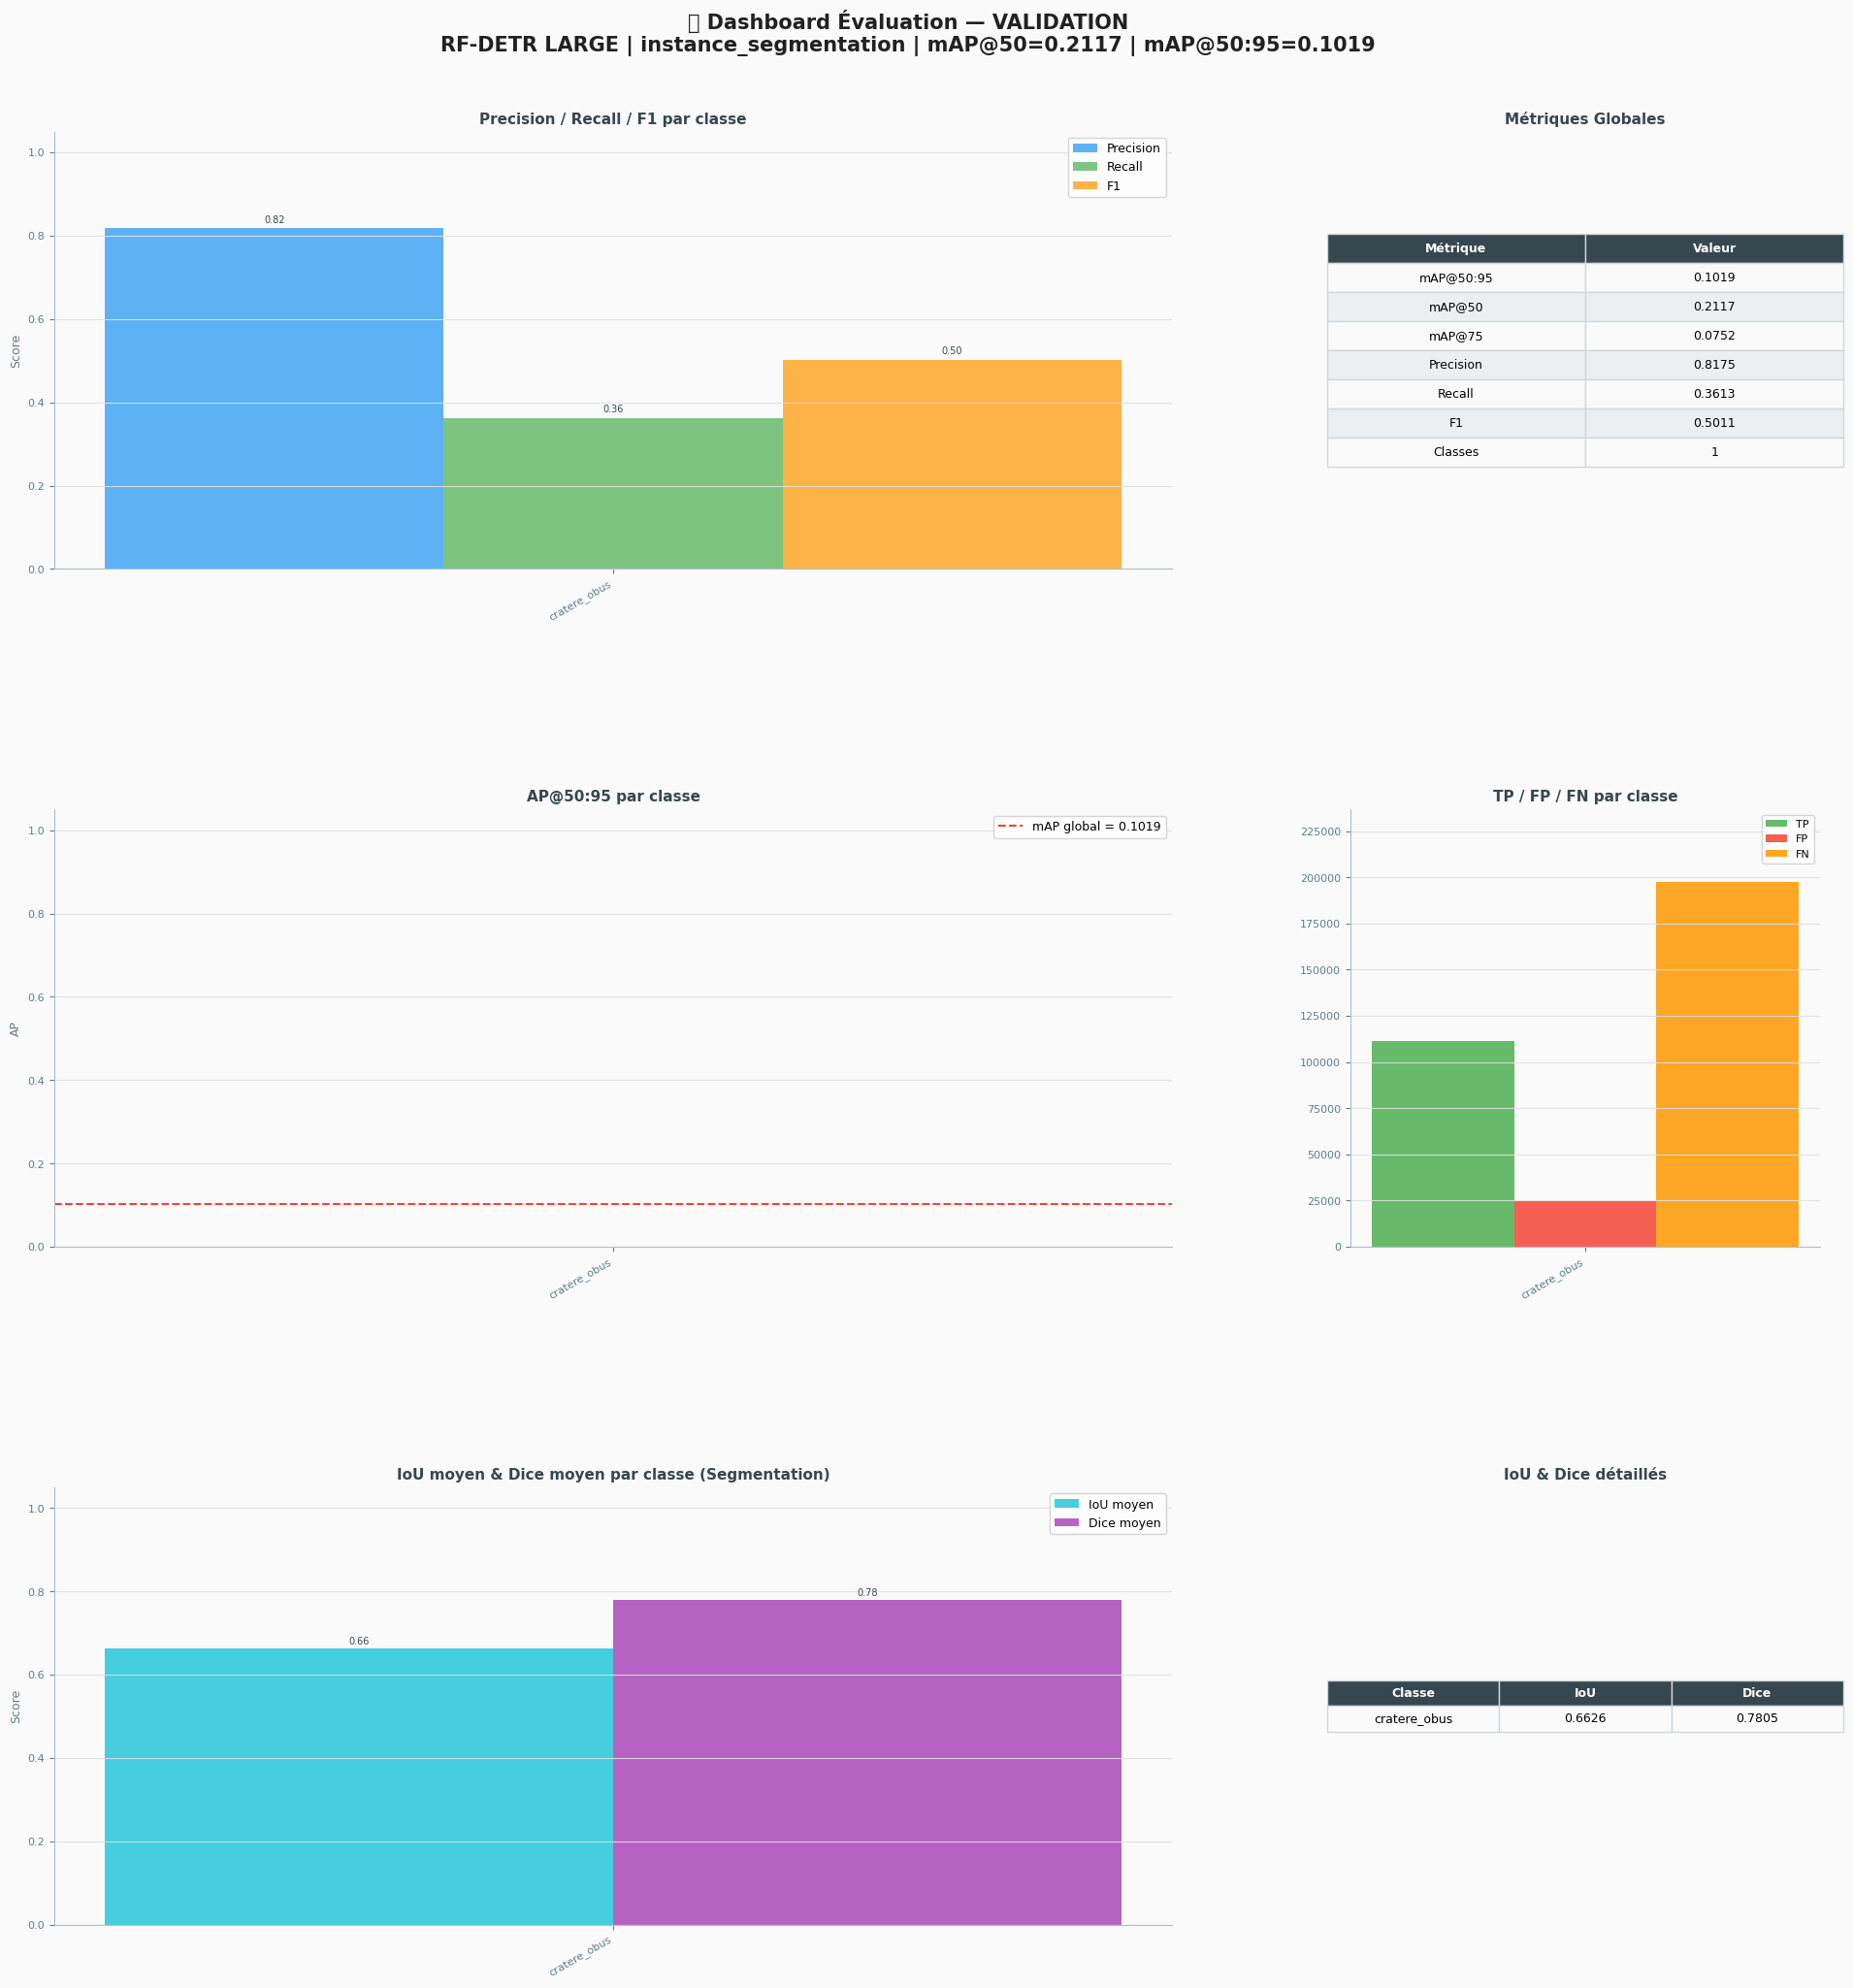

✅ Dashboard évaluation sauvegardé : /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_20260423_130530/visualizations/eval_dashboard_validation.png


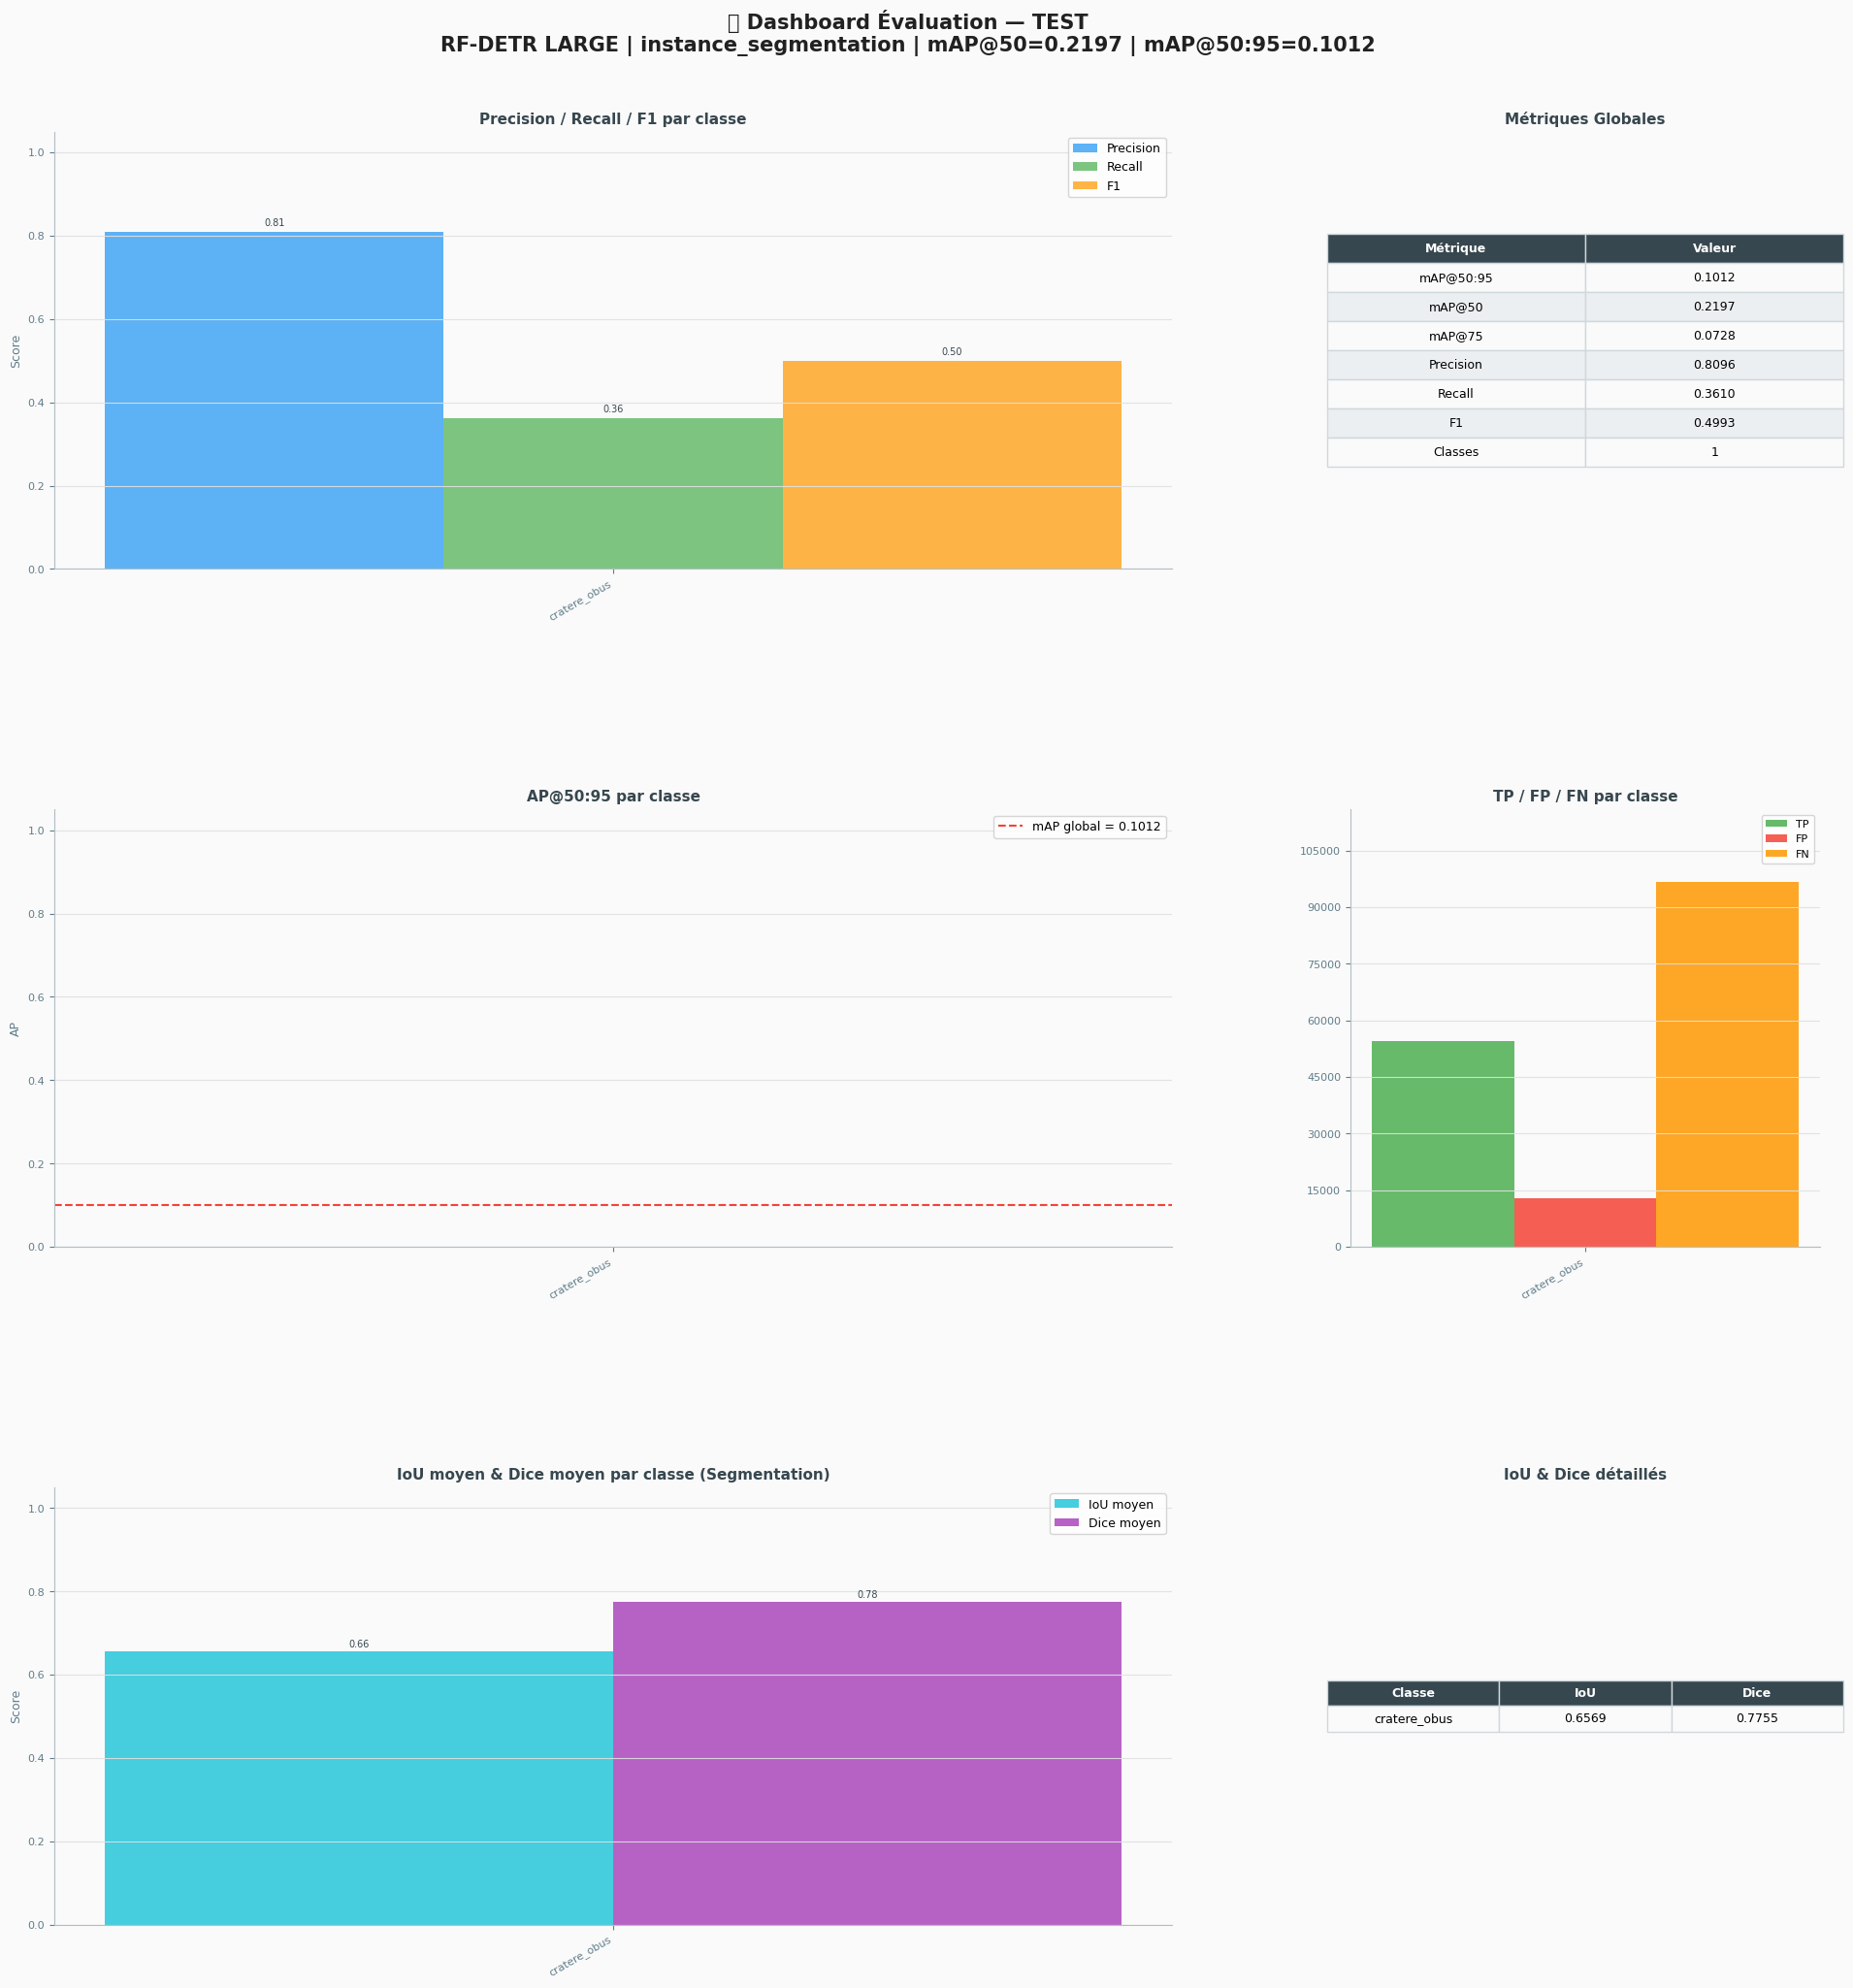

✅ Dashboard évaluation sauvegardé : /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_20260423_130530/visualizations/eval_dashboard_test.png


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import json
import os
from pathlib import Path

# ============================================================================
# HELPERS — Chargement des logs d'entraînement
# ============================================================================

def load_training_logs(training_path: str) -> dict:
    """
    Cherche les fichiers de logs générés par RF-DETR pendant l'entraînement.
    Supporte : log.txt (format JSON lines), metrics.json, summary.json
    Retourne un dict avec les séries temporelles.
    """
    logs = {
        'epochs': [],
        'train_loss': [],
        'val_loss': [],
        'mAP_50': [],
        'mAP_50_95': [],
        'lr': [],
    }

    # --- Tentative 0 : metrics.csv (Lightning CSVLogger, rfdetr >= 1.8) ---
    csv_file = os.path.join(training_path, 'metrics.csv')
    if os.path.exists(csv_file):
        import csv as _csv
        with open(csv_file) as f:
            rows = list(_csv.DictReader(f))
            # Si une reprise a sauvegarde les premieres epoques (metrics_avant_reprise.csv,
            # ecrit par la cellule 9ter), on la lit D'ABORD : si Lightning a ecrase
            # metrics.csv au redemarrage, la courbe complete reste reconstituable.
            import glob as _glob
            _bk = sorted(_glob.glob(os.path.join(training_path,
                                                 'metrics_avant_reprise_*.csv')))
            _legacy = os.path.join(training_path, 'metrics_avant_reprise.csv')
            if os.path.exists(_legacy):
                _bk.insert(0, _legacy)
            for _b in _bk:                       # anciennes d'abord, courante en dernier :
                with open(_b) as _fb:            # a epoque egale, la plus recente gagne
                    rows = list(_csv.DictReader(_fb)) + rows
            if _bk:
                print(f'   {len(_bk)} sauvegarde(s) de reprise fusionnee(s)')
        par_epoch = {}
        for r in rows:
            e = r.get('epoch')
            if e in (None, ''):
                continue
            d = par_epoch.setdefault(int(float(e)), {})
            for k, v in r.items():
                if v not in (None, ''):
                    d[k] = v
        if par_epoch:
            print(f"📂 Chargement logs : {csv_file}")
            cols = set().union(*par_epoch.values())
            # Choix DETERMINISTE : `cols` est un set, next() sur son iteration rendait une
            # colonne differente d'une execution a l'autre (constate : ema_mAP_50 puis
            # ema_segm_mAP_50, tracees sous la meme etiquette). Priorite explicite :
            # segm avant bbox (tache de segmentation), EMA avant brut (metrique de selection).
            def _prio(cands, priorite):
                for p in priorite:
                    if p in cands: return p
                return sorted(cands)[0] if cands else None
            cols_map = sorted(c for c in cols if 'map' in c.lower())
            col_5095 = _prio([c for c in cols_map if '50_95' in c],
                             ['val/ema_segm_mAP_50_95', 'val/segm_mAP_50_95',
                              'val/ema_mAP_50_95', 'val/mAP_50_95'])
            col_50 = _prio([c for c in cols_map
                            if '50' in c and '50_95' not in c and '75' not in c],
                           ['val/ema_segm_mAP_50', 'val/segm_mAP_50',
                            'val/ema_mAP_50', 'val/mAP_50'])

            def _col(*motifs):
                for m in motifs:
                    cands = [c for c in cols
                             if m in c.lower() and 'step' not in c.lower()]
                    if cands:
                        return sorted(cands, key=len)[0]
                return None

            assoc = [('train_loss', _col('train/loss', 'train_loss')),
                     ('val_loss', _col('val/loss', 'val_loss', 'test_loss')),
                     ('mAP_50', col_50), ('mAP_50_95', col_5095),
                     ('lr', _col('lr'))]
            # etiquettes exactes pour la legende (hors nettoyage : ce sont des chaines)
            logs['label_mAP_50'] = col_50 or 'mAP@50'
            logs['label_mAP_50_95'] = col_5095 or 'mAP@50:95'
            for e in sorted(par_epoch):
                d = par_epoch[e]
                logs['epochs'].append(e)
                for key, col in assoc:
                    try:
                        logs[key].append(float(d[col]))
                    except (KeyError, TypeError, ValueError):
                        logs[key].append(None)
            print(f"   ✅ {len(logs['epochs'])} epochs | "
                  f"colonnes retenues : {dict(assoc)}")
            for key in logs:
                if isinstance(logs[key], list):
                    logs[key] = [v for v in logs[key] if v is not None]
            return logs

    # --- Tentative 1 : log.txt (RF-DETR écrit une ligne JSON par epoch) ---
    log_file = os.path.join(training_path, 'output', 'log.txt')
    if not os.path.exists(log_file):
        log_file = os.path.join(training_path, 'log.txt')

    if os.path.exists(log_file):
        print(f"📂 Chargement logs : {log_file}")
        with open(log_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    entry = json.loads(line)
                    epoch = entry.get('epoch', len(logs['epochs']))
                    logs['epochs'].append(epoch)
                    logs['train_loss'].append(entry.get('train_loss',
                                              entry.get('loss', None)))
                    logs['val_loss'].append(entry.get('val_loss',
                                            entry.get('test_loss', None)))
                    logs['mAP_50'].append(entry.get('test_coco_eval_bbox_0',
                                          entry.get('mAP_50', None)))
                    logs['mAP_50_95'].append(entry.get('test_coco_eval_bbox',
                                             entry.get('mAP', None)))
                    logs['lr'].append(entry.get('train_lr',
                                      entry.get('lr', None)))
                except json.JSONDecodeError:
                    continue
        print(f"   ✅ {len(logs['epochs'])} epochs chargées")

    # --- Tentative 2 : metrics.json (sauvegardé à chaque checkpoint) ---
    elif os.path.exists(os.path.join(training_path, 'logs', 'metrics.json')):
        metrics_file = os.path.join(training_path, 'logs', 'metrics.json')
        print(f"📂 Chargement métriques : {metrics_file}")
        with open(metrics_file, 'r') as f:
            data = json.load(f)
        for i, entry in enumerate(data):
            logs['epochs'].append(entry.get('epoch', i))
            logs['train_loss'].append(entry.get('train_loss', None))
            logs['val_loss'].append(entry.get('val_loss', None))
            logs['mAP_50'].append(entry.get('mAP_50', None))
            logs['mAP_50_95'].append(entry.get('mAP_50_95', None))
            logs['lr'].append(entry.get('lr', None))

    else:
        print("⚠️  Aucun fichier de log trouvé. "
              "Graphe d'entraînement non disponible.")
        return None

    # Nettoyage : retirer les None
    for key in logs:
        if isinstance(logs[key], list):
            logs[key] = [v for v in logs[key] if v is not None]

    return logs


# ============================================================================
# PLOT 1 — Courbes d'entraînement
# ============================================================================

def plot_training_curves(training_path: str, save_path: str = None,
                         run_name: str = "") -> str:
    """
    Génère une image avec 4 graphiques :
      - Loss train vs val
      - mAP@50 et mAP@50:95
      - Learning Rate schedule
      - Tableau récapitulatif best epoch
    """
    logs = load_training_logs(training_path)

    if logs is None or len(logs['epochs']) == 0:
        print("❌ Impossible de générer les courbes : pas de données.")
        return None

    epochs = logs['epochs']

    # Palette
    COLOR_TRAIN   = '#2196F3'  # bleu
    COLOR_VAL     = '#F44336'  # rouge
    COLOR_MAP50   = '#4CAF50'  # vert
    COLOR_MAP5095 = '#FF9800'  # orange
    COLOR_LR      = '#9C27B0'  # violet
    BG_COLOR      = '#FAFAFA'
    GRID_COLOR    = '#E0E0E0'

    fig = plt.figure(figsize=(18, 12), facecolor=BG_COLOR)
    fig.suptitle(
        f"Courbes d'Entraînement — {run_name or FINAL_RUN_NAME}\n"
        f"RF-DETR {MODEL_VARIANT.upper()} | {TASK} | {len(epochs)} epochs",
        fontsize=16, fontweight='bold', color='#212121', y=0.98
    )

    gs = gridspec.GridSpec(2, 3, figure=fig,
                           hspace=0.40, wspace=0.35,
                           left=0.07, right=0.97,
                           top=0.91, bottom=0.08)

    ax_loss = fig.add_subplot(gs[0, :2])   # Loss (large)
    ax_map  = fig.add_subplot(gs[1, :2])   # mAP  (large)
    ax_lr   = fig.add_subplot(gs[0, 2])    # LR
    ax_tbl  = fig.add_subplot(gs[1, 2])    # Tableau

    def _style_ax(ax, title, xlabel, ylabel):
        ax.set_facecolor(BG_COLOR)
        ax.set_title(title, fontsize=12, fontweight='bold',
                     color='#37474F', pad=8)
        ax.set_xlabel(xlabel, fontsize=10, color='#607D8B')
        ax.set_ylabel(ylabel, fontsize=10, color='#607D8B')
        ax.grid(True, color=GRID_COLOR, linewidth=0.8, alpha=0.9)
        ax.spines[['top','right']].set_visible(False)
        ax.spines[['left','bottom']].set_color('#B0BEC5')
        ax.tick_params(colors='#607D8B', labelsize=9)

    # ── Loss ──────────────────────────────────────────────────────────────
    _style_ax(ax_loss, "Loss", "Epoch", "Loss")
    if logs['train_loss']:
        ax_loss.plot(epochs[:len(logs['train_loss'])],
                     logs['train_loss'],
                     color=COLOR_TRAIN, linewidth=2,
                     label='Train Loss', marker='o',
                     markersize=3, alpha=0.9)
    if logs['val_loss']:
        ax_loss.plot(epochs[:len(logs['val_loss'])],
                     logs['val_loss'],
                     color=COLOR_VAL, linewidth=2,
                     label='Val Loss', marker='s',
                     markersize=3, alpha=0.9)
        # Marquer le minimum
        min_idx = int(np.argmin(logs['val_loss']))
        ax_loss.axvline(x=epochs[min_idx], color=COLOR_VAL,
                        linestyle='--', alpha=0.4, linewidth=1)
        ax_loss.annotate(
            f"Best: {logs['val_loss'][min_idx]:.4f}\n(ep.{epochs[min_idx]})",
            xy=(epochs[min_idx], logs['val_loss'][min_idx]),
            xytext=(10, 10), textcoords='offset points',
            fontsize=8, color=COLOR_VAL,
            arrowprops=dict(arrowstyle='->', color=COLOR_VAL, lw=1)
        )
    ax_loss.legend(framealpha=0.8, fontsize=9)

    # ── mAP ───────────────────────────────────────────────────────────────
    _style_ax(ax_map, "Mean Average Precision", "Epoch", "mAP")
    if logs['mAP_50']:
        ax_map.plot(epochs[:len(logs['mAP_50'])],
                    logs['mAP_50'],
                    color=COLOR_MAP50, linewidth=2,
                    label=logs.get('label_mAP_50', 'mAP@50'), marker='o',
                    markersize=3, alpha=0.9)
        max_idx = int(np.argmax(logs['mAP_50']))
        ax_map.annotate(
            f"Best mAP@50: {logs['mAP_50'][max_idx]:.4f}\n(ep.{epochs[max_idx]})",
            xy=(epochs[max_idx], logs['mAP_50'][max_idx]),
            xytext=(10, -15), textcoords='offset points',
            fontsize=8, color=COLOR_MAP50,
            arrowprops=dict(arrowstyle='->', color=COLOR_MAP50, lw=1)
        )
    if logs['mAP_50_95']:
        ax_map.plot(epochs[:len(logs['mAP_50_95'])],
                    logs['mAP_50_95'],
                    color=COLOR_MAP5095, linewidth=2,
                    label=logs.get('label_mAP_50_95', 'mAP@50:95'), marker='s',
                    markersize=3, alpha=0.9)
    # borne adaptee aux donnees : un axe 0-1 ecrase des courbes qui plafonnent a 0,16
    _ymax = max([v for v in logs['mAP_50'] + logs['mAP_50_95'] if v is not None] or [1.0])
    ax_map.set_ylim(0, min(1.05, _ymax * 1.3 + 0.02))
    ax_map.legend(framealpha=0.8, fontsize=9)

    # ── Learning Rate ──────────────────────────────────────────────────────
    _style_ax(ax_lr, "Learning Rate", "Epoch", "LR")
    if logs['lr']:
        ax_lr.plot(epochs[:len(logs['lr'])],
                   logs['lr'],
                   color=COLOR_LR, linewidth=1.5,
                   marker='o', markersize=2)
        ax_lr.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x:.2e}')
        )

    # ── Tableau récapitulatif ──────────────────────────────────────────────
    ax_tbl.axis('off')
    ax_tbl.set_facecolor(BG_COLOR)
    ax_tbl.set_title("Récapitulatif", fontsize=12,
                      fontweight='bold', color='#37474F', pad=8)

    summary_rows = []
    if logs['mAP_50']:
        best_e = epochs[int(np.argmax(logs['mAP_50']))]
        summary_rows.append(["Best mAP@50 epoch", str(best_e)])
        summary_rows.append(["Best mAP@50",
                              f"{max(logs['mAP_50']):.4f}"])
    if logs['mAP_50_95']:
        summary_rows.append(["Best mAP@50:95",
                              f"{max(logs['mAP_50_95']):.4f}"])
    if logs['val_loss']:
        summary_rows.append(["Min Val Loss",
                              f"{min(logs['val_loss']):.4f}"])
    if logs['train_loss']:
        summary_rows.append(["Min Train Loss",
                              f"{min(logs['train_loss']):.4f}"])
    summary_rows.append(["Total epochs", str(len(epochs))])
    summary_rows.append(["Modèle", f"RF-DETR {MODEL_VARIANT.upper()}"])
    summary_rows.append(["Résolution", str(RESOLUTION)])

    if summary_rows:
        tbl = ax_tbl.table(
            cellText=summary_rows,
            colLabels=["Métrique", "Valeur"],
            loc='center', cellLoc='center'
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.1, 1.6)
        for (row, col), cell in tbl.get_celld().items():
            if row == 0:
                cell.set_facecolor('#37474F')
                cell.set_text_props(color='white', fontweight='bold')
            elif row % 2 == 0:
                cell.set_facecolor('#ECEFF1')
            else:
                cell.set_facecolor('#FAFAFA')
            cell.set_edgecolor('#CFD8DC')

    # ── Sauvegarde ────────────────────────────────────────────────────────
    if save_path is None:
        save_path = os.path.join(TARGET_TRAINING_PATH,
                                 'visualizations',
                                 'training_curves.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=BG_COLOR)
    plt.show()
    print(f"✅ Courbes d'entraînement sauvegardées : {save_path}")
    return save_path


# ============================================================================
# PLOT 2 — Dashboard métriques d'évaluation (test/val)
# ============================================================================

def plot_evaluation_dashboard(eval_results: dict,
                               split_name: str = "Test",
                               save_path: str = None) -> str:
    """
    Génère un dashboard complet des métriques d'évaluation :
      - Barres Precision / Recall / F1 par classe
      - Barres mAP par classe
      - Matrice de confusion simplifiée (TP/FP/FN)
      - Tableau global
      - (Seg only) IoU et Dice par classe
    """
    if eval_results is None:
        print(f"❌ Pas de résultats pour '{split_name}'")
        return None

    global_m   = eval_results.get('global_metrics', {})
    per_class  = eval_results.get('per_class', {})
    task       = eval_results.get('task', TASK)

    classes    = list(per_class.keys())
    n_classes  = len(classes)

    # Données par classe
    precisions = [per_class[c].get('precision', 0) for c in classes]
    recalls    = [per_class[c].get('recall',    0) for c in classes]
    f1s        = [per_class[c].get('f1',        0) for c in classes]
    aps        = [per_class[c].get('ap_50_95',  0) for c in classes]
    tps        = [per_class[c].get('tp', 0) for c in classes]
    fps        = [per_class[c].get('fp', 0) for c in classes]
    fns        = [per_class[c].get('fn', 0) for c in classes]

    is_seg = (task == "instance_segmentation")
    if is_seg:
        ious  = [per_class[c].get('iou_mean',  0) for c in classes]
        dices = [per_class[c].get('dice_mean', 0) for c in classes]

    # Mise en page
    n_rows = 3 if is_seg else 2
    BG     = '#FAFAFA'
    fig    = plt.figure(figsize=(20, 7 * n_rows), facecolor=BG)
    fig.suptitle(
        f"📊 Dashboard Évaluation — {split_name.upper()}\n"
        f"RF-DETR {MODEL_VARIANT.upper()} | {task} | "
        f"mAP@50={global_m.get('mAP_50', 0):.4f} | "
        f"mAP@50:95={global_m.get('mAP_50_95', 0):.4f}",
        fontsize=15, fontweight='bold', color='#212121', y=0.99
    )

    gs = gridspec.GridSpec(n_rows, 3, figure=fig,
                           hspace=0.55, wspace=0.38,
                           left=0.06, right=0.97,
                           top=0.93, bottom=0.05)

    x      = np.arange(n_classes)
    width  = 0.25
    colors = plt.cm.Set3(np.linspace(0, 1, max(n_classes, 3)))

    def _style(ax, title, xlabel='', ylabel='', ylim=(0, 1.05)):
        ax.set_facecolor(BG)
        ax.set_title(title, fontsize=11, fontweight='bold',
                     color='#37474F', pad=6)
        ax.set_xlabel(xlabel, fontsize=9, color='#607D8B')
        ax.set_ylabel(ylabel, fontsize=9, color='#607D8B')
        if ylim:
            ax.set_ylim(*ylim)
        ax.grid(axis='y', color='#E0E0E0', linewidth=0.8, alpha=0.9)
        ax.spines[['top','right']].set_visible(False)
        ax.spines[['left','bottom']].set_color('#B0BEC5')
        ax.tick_params(colors='#607D8B', labelsize=8)
        if n_classes > 0:
            ax.set_xticks(x)
            ax.set_xticklabels(classes, rotation=30,
                               ha='right', fontsize=8)

    # ── Ligne 1 : Precision / Recall / F1 ─────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    _style(ax1, "Precision / Recall / F1 par classe", ylabel="Score")
    bars1 = ax1.bar(x - width, precisions, width,
                    label='Precision', color='#42A5F5', alpha=0.85)
    bars2 = ax1.bar(x,          recalls,   width,
                    label='Recall',    color='#66BB6A', alpha=0.85)
    bars3 = ax1.bar(x + width,  f1s,       width,
                    label='F1',        color='#FFA726', alpha=0.85)

    # Valeurs sur les barres
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0.01:
                ax1.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                         f'{h:.2f}', ha='center', va='bottom',
                         fontsize=7, color='#37474F')
    ax1.legend(fontsize=9, framealpha=0.8)

    # ── Ligne 1 : Tableau global ───────────────────────────────────────────
    ax_g = fig.add_subplot(gs[0, 2])
    ax_g.axis('off')
    ax_g.set_facecolor(BG)
    ax_g.set_title("Métriques Globales", fontsize=11,
                   fontweight='bold', color='#37474F', pad=6)

    global_rows = [
        ["mAP@50:95", f"{global_m.get('mAP_50_95', 0):.4f}"],
        ["mAP@50",    f"{global_m.get('mAP_50',    0):.4f}"],
        ["mAP@75",    f"{global_m.get('mAP_75',    0):.4f}"],
        ["Precision", f"{global_m.get('precision', 0):.4f}"],
        ["Recall",    f"{global_m.get('recall',    0):.4f}"],
        ["F1",        f"{global_m.get('f1',        0):.4f}"],
        ["Classes",   str(n_classes)],
    ]
    tbl = ax_g.table(cellText=global_rows,
                     colLabels=["Métrique", "Valeur"],
                     loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#37474F')
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#ECEFF1')
        else:
            cell.set_facecolor('#FAFAFA')
        cell.set_edgecolor('#CFD8DC')

    # ── Ligne 2 : mAP par classe ───────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :2])
    _style(ax2, "AP@50:95 par classe", ylabel="AP")
    bar_colors = [colors[i % len(colors)] for i in range(n_classes)]
    ax2.bar(x, aps, color=bar_colors, alpha=0.85, edgecolor='white')
    ax2.axhline(y=global_m.get('mAP_50_95', 0),
                color='#F44336', linewidth=1.5,
                linestyle='--',
                label=f"mAP global = {global_m.get('mAP_50_95',0):.4f}")
    for i, v in enumerate(aps):
        if v > 0.01:
            ax2.text(i, v + 0.01, f'{v:.2f}',
                     ha='center', fontsize=7, color='#37474F')
    ax2.legend(fontsize=9)

    # ── Ligne 2 : TP / FP / FN ────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    _style(ax3, "TP / FP / FN par classe",
           ylim=(0, max(max(tps+fps+fns, default=1) * 1.2, 1)))
    ax3.bar(x - width, tps, width, label='TP',
            color='#4CAF50', alpha=0.85)
    ax3.bar(x,          fps, width, label='FP',
            color='#F44336', alpha=0.85)
    ax3.bar(x + width,  fns, width, label='FN',
            color='#FF9800', alpha=0.85)
    ax3.legend(fontsize=8)
    ax3.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # ── Ligne 3 (seg only) : IoU & Dice ───────────────────────────────────
    if is_seg:
        ax4 = fig.add_subplot(gs[2, :2])
        _style(ax4, "IoU moyen & Dice moyen par classe (Segmentation)",
               ylabel="Score")
        ax4.bar(x - width/2, ious,  width,
                label='IoU moyen',  color='#26C6DA', alpha=0.85)
        ax4.bar(x + width/2, dices, width,
                label='Dice moyen', color='#AB47BC', alpha=0.85)
        for i, (iv, dv) in enumerate(zip(ious, dices)):
            if iv > 0.01:
                ax4.text(i - width/2, iv + 0.01, f'{iv:.2f}',
                         ha='center', fontsize=7, color='#37474F')
            if dv > 0.01:
                ax4.text(i + width/2, dv + 0.01, f'{dv:.2f}',
                         ha='center', fontsize=7, color='#37474F')
        ax4.legend(fontsize=9)

        # Tableau IoU / Dice
        ax5 = fig.add_subplot(gs[2, 2])
        ax5.axis('off')
        ax5.set_title("IoU & Dice détaillés", fontsize=11,
                      fontweight='bold', color='#37474F', pad=6)
        seg_rows = [[c,
                     f"{per_class[c].get('iou_mean', 0):.4f}",
                     f"{per_class[c].get('dice_mean',0):.4f}"]
                    for c in classes]
        tbl2 = ax5.table(cellText=seg_rows,
                         colLabels=["Classe", "IoU", "Dice"],
                         loc='center', cellLoc='center')
        tbl2.auto_set_font_size(False)
        tbl2.set_fontsize(9)
        tbl2.scale(1.1, 1.6)
        for (row, col), cell in tbl2.get_celld().items():
            if row == 0:
                cell.set_facecolor('#37474F')
                cell.set_text_props(color='white', fontweight='bold')
            elif row % 2 == 0:
                cell.set_facecolor('#ECEFF1')
            else:
                cell.set_facecolor('#FAFAFA')
            cell.set_edgecolor('#CFD8DC')

    # ── Sauvegarde ────────────────────────────────────────────────────────
    if save_path is None:
        tag = split_name.lower().replace(' ', '_')
        save_path = os.path.join(TARGET_TRAINING_PATH,
                                 'visualizations',
                                 f'eval_dashboard_{tag}.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print(f"✅ Dashboard évaluation sauvegardé : {save_path}")
    return save_path


# ============================================================================
# APPELS — À exécuter après l'étape 11
# ============================================================================

# Courbes d'entraînement
plot_training_curves(
    training_path=TARGET_TRAINING_PATH,
    run_name=FINAL_RUN_NAME
)

# Dashboard validation
if 'val_results' in dir() and val_results is not None:
    plot_evaluation_dashboard(
        eval_results=val_results,
        split_name="Validation"
    )

# Dashboard test
if 'test_results' in dir() and test_results is not None:
    plot_evaluation_dashboard(
        eval_results=test_results,
        split_name="Test"
    )


## 13. Visualisation des Prédictions

- **Segmentation** : 4 colonnes (original / GT masques / Pred masques / Superposition)
- **Détection**    : 3 colonnes (original / GT bbox / Pred bbox)

In [ ]:
import matplotlib.patches as mpatches

NUM_SAMPLES = "all"           # ou un int pour limiter
VISUALIZATION_SPLIT = "test"  # "test" ou "valid"

_HEX_PALETTE = [
    "#ffff00","#ff9b00","#ff8080","#ff66b2","#ff66ff","#b266ff",
    "#9999ff","#3399ff","#66ffff","#33ff99","#66ff66","#99ff00"
]
_RGB_PALETTE = [tuple(int(h.lstrip('#')[i:i+2],16) for i in (0,2,4)) for h in _HEX_PALETTE]


def _color_for_idx(idx):
    return _RGB_PALETTE[idx % len(_RGB_PALETTE)]


def _masks_to_xyxy(masks):
    n = masks.shape[0]
    xyxy = np.zeros((n,4), dtype=np.float32)
    for i in range(n):
        rows = np.any(masks[i], axis=1); cols = np.any(masks[i], axis=0)
        if not np.any(rows): continue
        y0,y1 = np.where(rows)[0][[0,-1]]
        x0,x1 = np.where(cols)[0][[0,-1]]
        xyxy[i] = [x0,y0,x1+1,y1+1]
    return xyxy


def build_gt_detections_seg(img_info, anns_by_img, rfdetr_class_map, img_w, img_h):
    """Reconstruit sv.Detections GT avec masques (segmentation)."""
    gt_anns = anns_by_img.get(img_info['id'], [])
    if not gt_anns: return None
    masks_list, class_ids, confs = [], [], []
    for ann in gt_anns:
        ri = rfdetr_class_map.get(ann['category_id'])
        if ri is None: continue
        seg = ann.get('segmentation')
        if not seg: continue
        try: m = decode_coco_segmentation(seg, img_h, img_w)
        except Exception: continue
        if m.shape != (img_h, img_w): continue
        masks_list.append(m); class_ids.append(ri); confs.append(1.0)
    if not masks_list: return None
    masks_arr = np.stack(masks_list, axis=0)
    return sv.Detections(xyxy=_masks_to_xyxy(masks_arr), mask=masks_arr,
                         class_id=np.array(class_ids, dtype=int),
                         confidence=np.array(confs, dtype=float))


def build_gt_detections_det(img_info, anns_by_img, rfdetr_class_map):
    """Reconstruit sv.Detections GT avec bboxes (détection)."""
    gt_anns = anns_by_img.get(img_info['id'], [])
    if not gt_anns: return None
    boxes, class_ids, confs = [], [], []
    for ann in gt_anns:
        ri = rfdetr_class_map.get(ann['category_id'])
        if ri is None: continue
        boxes.append(coco_bbox_to_xyxy(ann['bbox']))
        class_ids.append(ri); confs.append(1.0)
    if not boxes: return None
    return sv.Detections(xyxy=np.array(boxes, dtype=np.float32),
                         class_id=np.array(class_ids, dtype=int),
                         confidence=np.array(confs, dtype=float))


def _annotate_no_labels_seg(image, detections):
    """Masques colorés + contours, sans labels texte."""
    if detections is None or len(detections) == 0: return image.copy()
    cp = sv.ColorPalette.from_hex(_HEX_PALETTE)
    out = image.copy()
    out = sv.MaskAnnotator(color=cp, opacity=0.35).annotate(out, detections)
    out = sv.PolygonAnnotator(color=cp, thickness=2).annotate(out, detections)
    return out


def _annotate_no_labels_det(image, detections):
    """Bboxes colorées, sans labels texte."""
    if detections is None or len(detections) == 0: return image.copy()
    cp = sv.ColorPalette.from_hex(_HEX_PALETTE)
    th = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
    out = image.copy()
    out = sv.BoxAnnotator(color=cp, thickness=th).annotate(out, detections)
    return out


def _make_legend_image(rfdetr_label_map, img_h=400, img_w=300):
    """Image PIL contenant la légende des classes."""
    fig, ax = plt.subplots(figsize=(img_w/100, img_h/100), dpi=100)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.set_title("Légende des classes", fontsize=13, fontweight='bold', pad=10)
    sorted_idx = sorted(rfdetr_label_map.keys())
    n = len(sorted_idx); spacing = min(0.08, 0.9/max(n,1)); y0 = 0.92
    for i, idx in enumerate(sorted_idx):
        r,g,b = _color_for_idx(idx)
        color = (r/255, g/255, b/255); y = y0 - i*spacing
        ax.add_patch(mpatches.FancyBboxPatch((0.05,y-0.02),0.08,0.04,
            boxstyle="round,pad=0.005", facecolor=color, edgecolor='black', linewidth=0.8))
        ax.text(0.18, y, f"[{idx}] {rfdetr_label_map[idx]}", fontsize=10,
                va='center', fontfamily='monospace')
    fig.tight_layout(); fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    legend = Image.frombytes('RGBA', fig.canvas.get_width_height(), buf)
    plt.close(fig)
    return legend.convert('RGB')


def visualize_prediction(model, image_path, rfdetr_label_map, rfdetr_class_map,
                         anns_by_img, imgs_by_name, task, threshold=0.3, save_path=None):
    """
    Visualise une prédiction.
    Seg: 4 colonnes (original / GT / Pred / Superposition GT+Pred)
    Det: 3 colonnes (original / GT / Pred)
    """
    image = Image.open(image_path); img_w, img_h = image.size
    filename = os.path.basename(image_path)

    detections = model.predict(image, threshold=threshold,
                                shape=(RESOLUTION, RESOLUTION))

    img_info = imgs_by_name.get(filename)
    gt_det = None
    if img_info is not None:
        if task == "instance_segmentation":
            gt_det = build_gt_detections_seg(img_info, anns_by_img, rfdetr_class_map, img_w, img_h)
        else:
            gt_det = build_gt_detections_det(img_info, anns_by_img, rfdetr_class_map)

    n_gt = len(gt_det) if gt_det is not None else 0
    n_pred = len(detections) if detections is not None else 0

    if task == "instance_segmentation":
        _ann_fn = _annotate_no_labels_seg
        col1 = image.copy()
        col2 = _ann_fn(image, gt_det)
        col3 = _ann_fn(image, detections)
        col4 = _ann_fn(image, detections)
        if gt_det is not None and len(gt_det) > 0:
            col4 = sv.PolygonAnnotator(color=sv.Color.WHITE, thickness=3).annotate(col4, gt_det)

        fig, axes = plt.subplots(1, 4, figsize=(28, 6))
        for ax, img, title in zip(axes,
            [col1, col2, col3, col4],
            ["Image originale", f"Ground Truth ({n_gt})", f"Prédictions ({n_pred})",
             "Superposition (GT=contours blancs)"]):
            ax.imshow(img); ax.set_title(title, fontsize=11, fontweight='bold'); ax.axis('off')
    else:
        _ann_fn = _annotate_no_labels_det
        col1 = image.copy()
        col2 = _ann_fn(image, gt_det)
        col3 = _ann_fn(image, detections)

        fig, axes = plt.subplots(1, 3, figsize=(21, 6))
        for ax, img, title in zip(axes,
            [col1, col2, col3],
            ["Image originale", f"Ground Truth ({n_gt})", f"Prédictions ({n_pred})"]):
            ax.imshow(img); ax.set_title(title, fontsize=11, fontweight='bold'); ax.axis('off')

    plt.suptitle(filename, fontsize=10, y=1.01); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close(fig)
    else:
        plt.show()
    return detections


def visualize_all_predictions(model, dataset_dir, split, rfdetr_label_map, rfdetr_class_map,
                               num_samples, save_dir, task, threshold=0.3):
    """Visualise et sauvegarde les prédictions sur un split complet."""
    split_dir = os.path.join(dataset_dir, split)
    ann_file = os.path.join(split_dir, '_annotations.coco.json')

    anns_by_img = defaultdict(list)
    imgs_by_name = {}
    if os.path.exists(ann_file):
        with open(ann_file, 'r') as f:
            cd = json.load(f)
        for img in cd['images']:
            imgs_by_name[img['file_name']] = img
        for ann in cd['annotations']:
            anns_by_img[ann['image_id']].append(ann)

    # Légende
    legend = _make_legend_image(rfdetr_label_map)
    legend.save(os.path.join(save_dir, 'legend.png'))
    print(f"📋 Légende: {os.path.join(save_dir, 'legend.png')}")

    image_files = sorted([f for f in os.listdir(split_dir)
                          if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
    total = len(image_files)
    if num_samples == "all":
        num_samples = total; indices = list(range(total))
    else:
        num_samples = min(num_samples, total)
        np.random.seed(42)
        indices = np.random.choice(total, num_samples, replace=False).tolist()

    print(f"🖼️  {num_samples} visualisations sur '{split}'...")
    saved = []
    for i, idx in enumerate(indices):
        sp = os.path.join(save_dir, f'prediction_{idx:04d}.png')
        visualize_prediction(model, os.path.join(split_dir, image_files[idx]),
                             rfdetr_label_map, rfdetr_class_map,
                             anns_by_img, imgs_by_name, task, threshold, sp)
        saved.append(sp)
        if (i+1) % 10 == 0 or (i+1) == num_samples:
            print(f"   [{i+1}/{num_samples}]")
    return saved


# ============================================================================
# LANCEMENT DE LA VISUALISATION
# ============================================================================
viz_split = VISUALIZATION_SPLIT
if not os.path.exists(os.path.join(DATASET_DIR, viz_split)):
    viz_split = "valid"

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
viz_session_dir = os.path.join(VIS_DIR, f"viz_{viz_split}_{ts}")
os.makedirs(viz_session_dir, exist_ok=True)

saved_files = visualize_all_predictions(
    model, DATASET_DIR, viz_split, rfdetr_label_map, rfdetr_class_map,
    NUM_SAMPLES, viz_session_dir, TASK, CONFIDENCE_THRESHOLD
)
print(f"✅ {len(saved_files)} visualisations: {viz_session_dir}")


📋 Légende: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_20260423_130530/visualizations/viz_test_20260423_193248/legend.png
🖼️  412 visualisations sur 'test'...
   [10/412]
   [20/412]
   [30/412]
   [40/412]
   [50/412]
   [60/412]
   [70/412]
   [80/412]
   [90/412]
   [100/412]
   [110/412]
   [120/412]
   [130/412]
   [140/412]
   [150/412]
   [160/412]
   [170/412]
   [180/412]
   [190/412]
   [200/412]
   [210/412]
   [220/412]
   [230/412]
   [240/412]
   [250/412]
   [260/412]
   [270/412]
   [280/412]
   [290/412]
   [300/412]
   [310/412]
   [320/412]
   [330/412]
   [340/412]
   [350/412]
   [360/412]
   [370/412]
   [380/412]
   [390/412]
   [400/412]
   [410/412]
   [412/412]
✅ 412 visualisations: /content/drive/MyDrive/Archeologia/Archeologia_Shared/model-training/verdun/verdun_1_class/runs/training/verdun_ld_cratere_circulaire_20260423_130530/visualizations/viz_test_20260423_193248


## 14. Visualisation Rapide (quelques exemples inline)

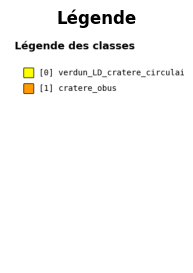


📷 tile_0051_0050_png.rf.b171fa1c9853a7ac42b7a256c4ab552c.jpg


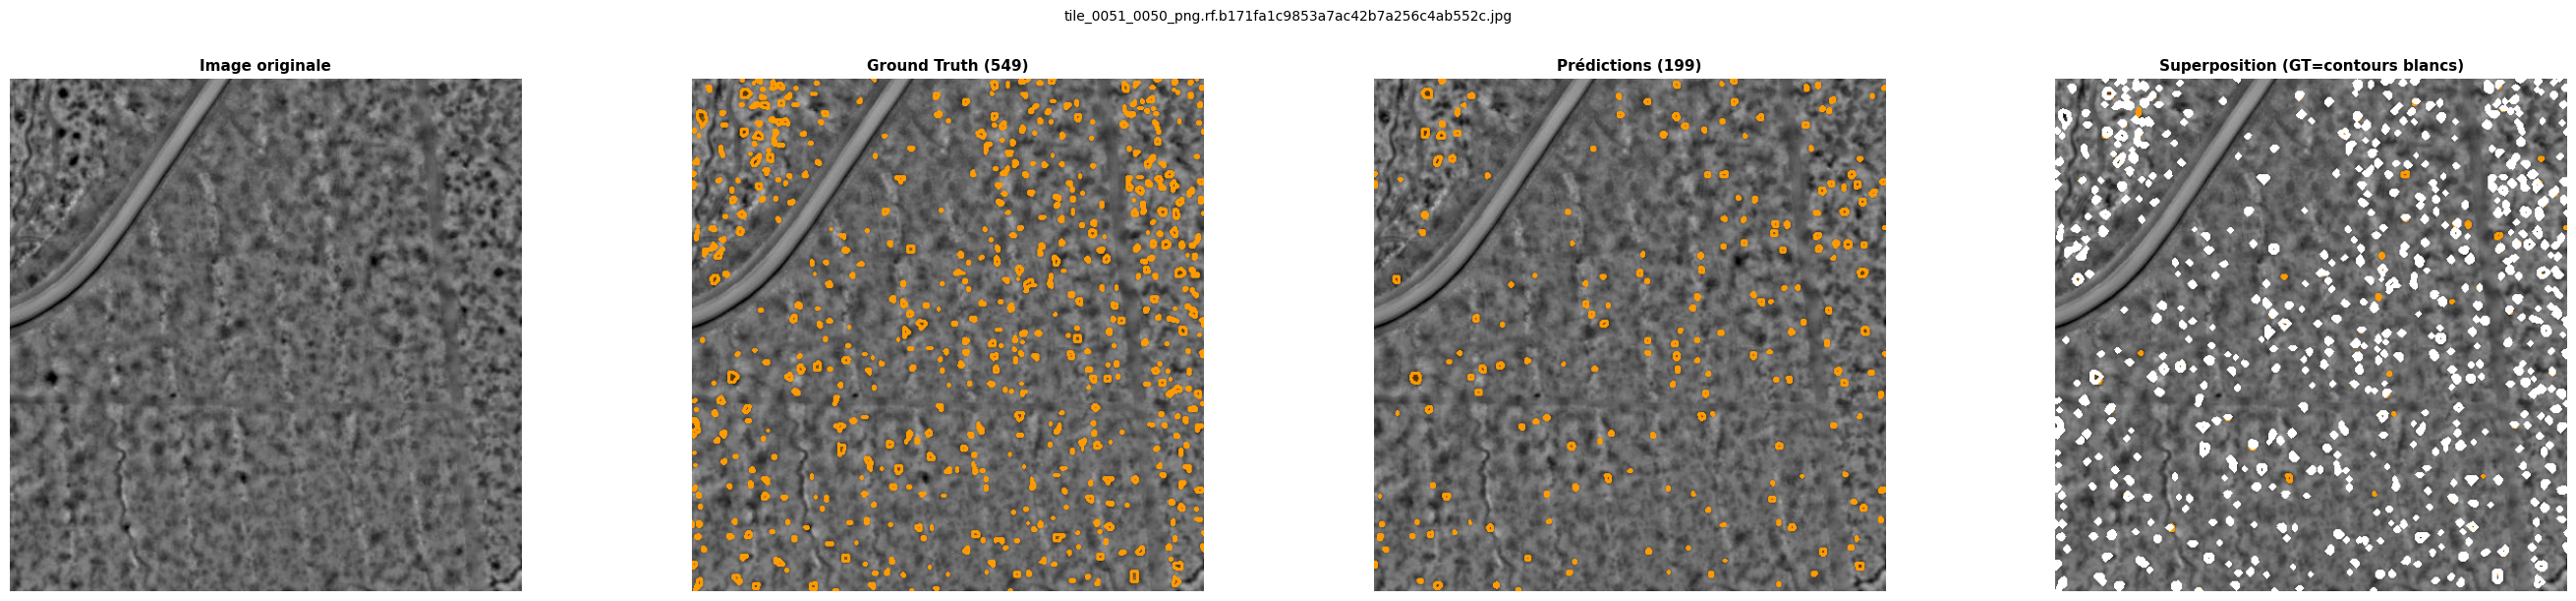


📷 tile_0021_0001_png.rf.e24ad42c313de369e8535ae7414aeab5.jpg


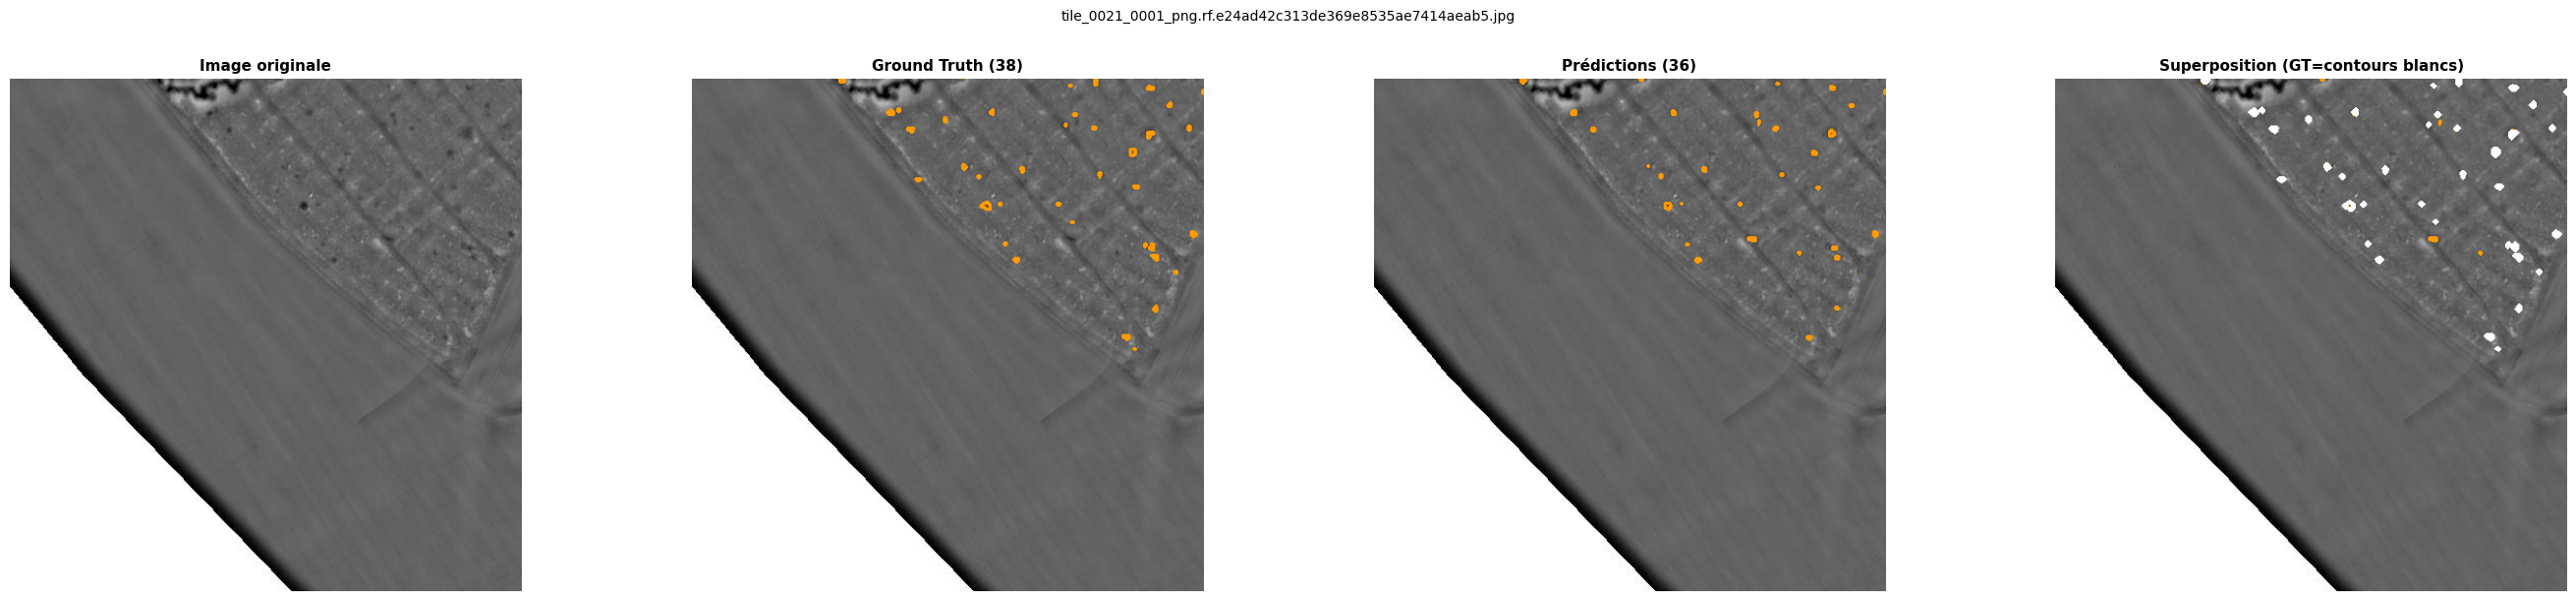


📷 tile_0044_0058_png.rf.0a89357f0a78d8c598e5d41811fc4a8f.jpg


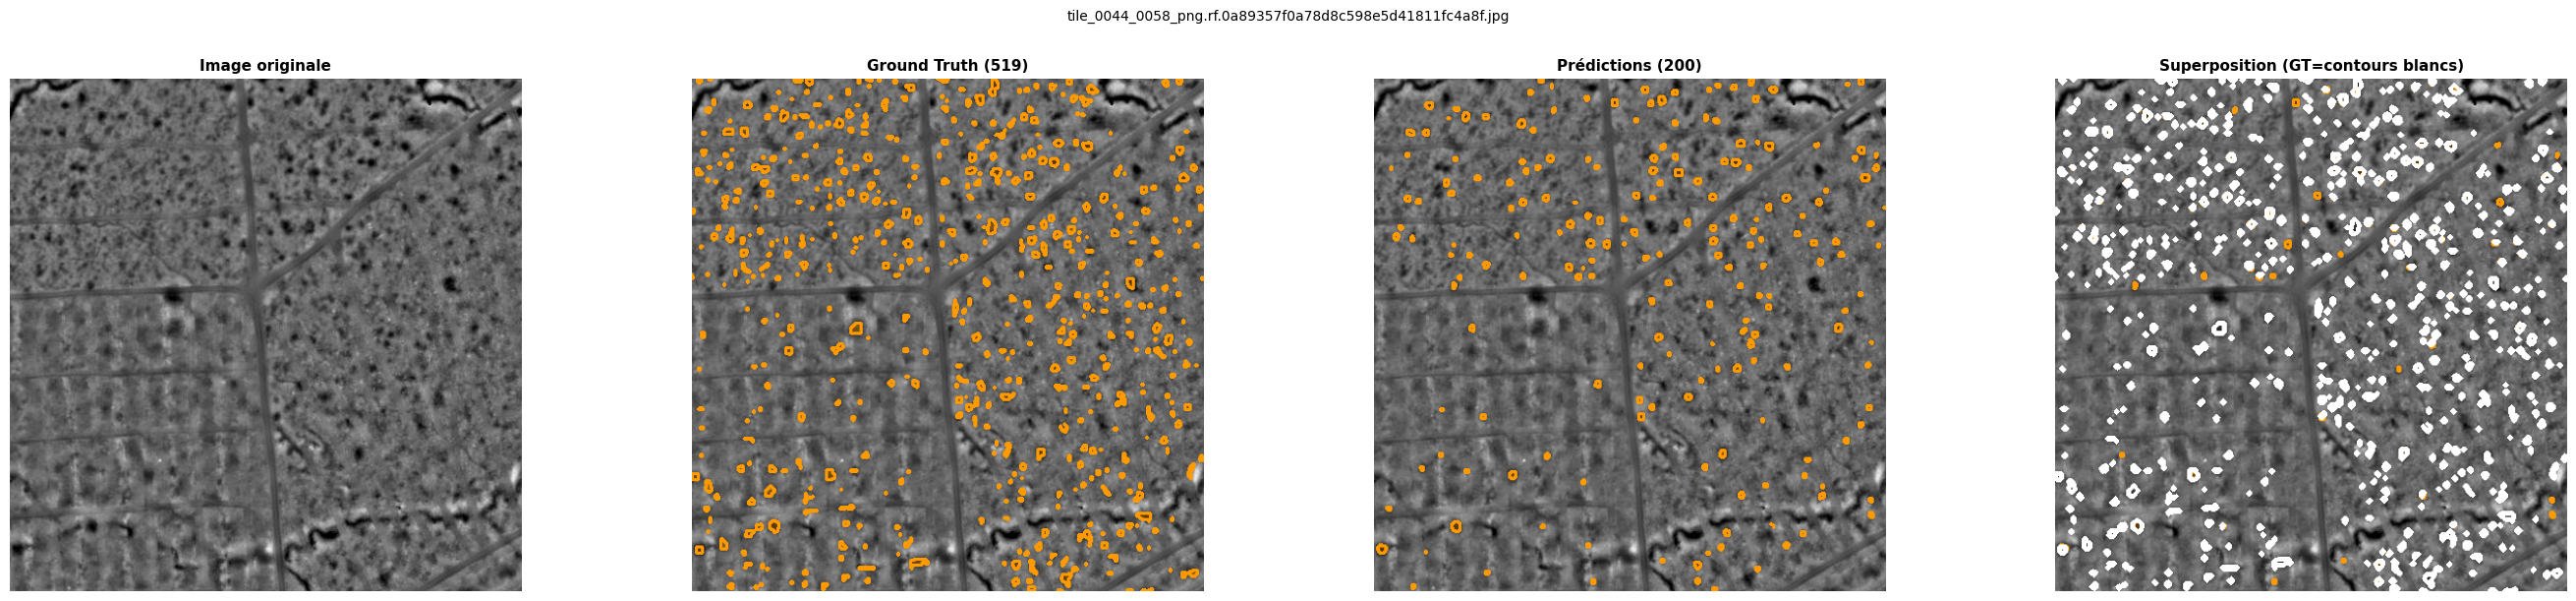


📷 tile_0015_0056_png.rf.c2ac90f526608384453a3c038f36ff6d.jpg


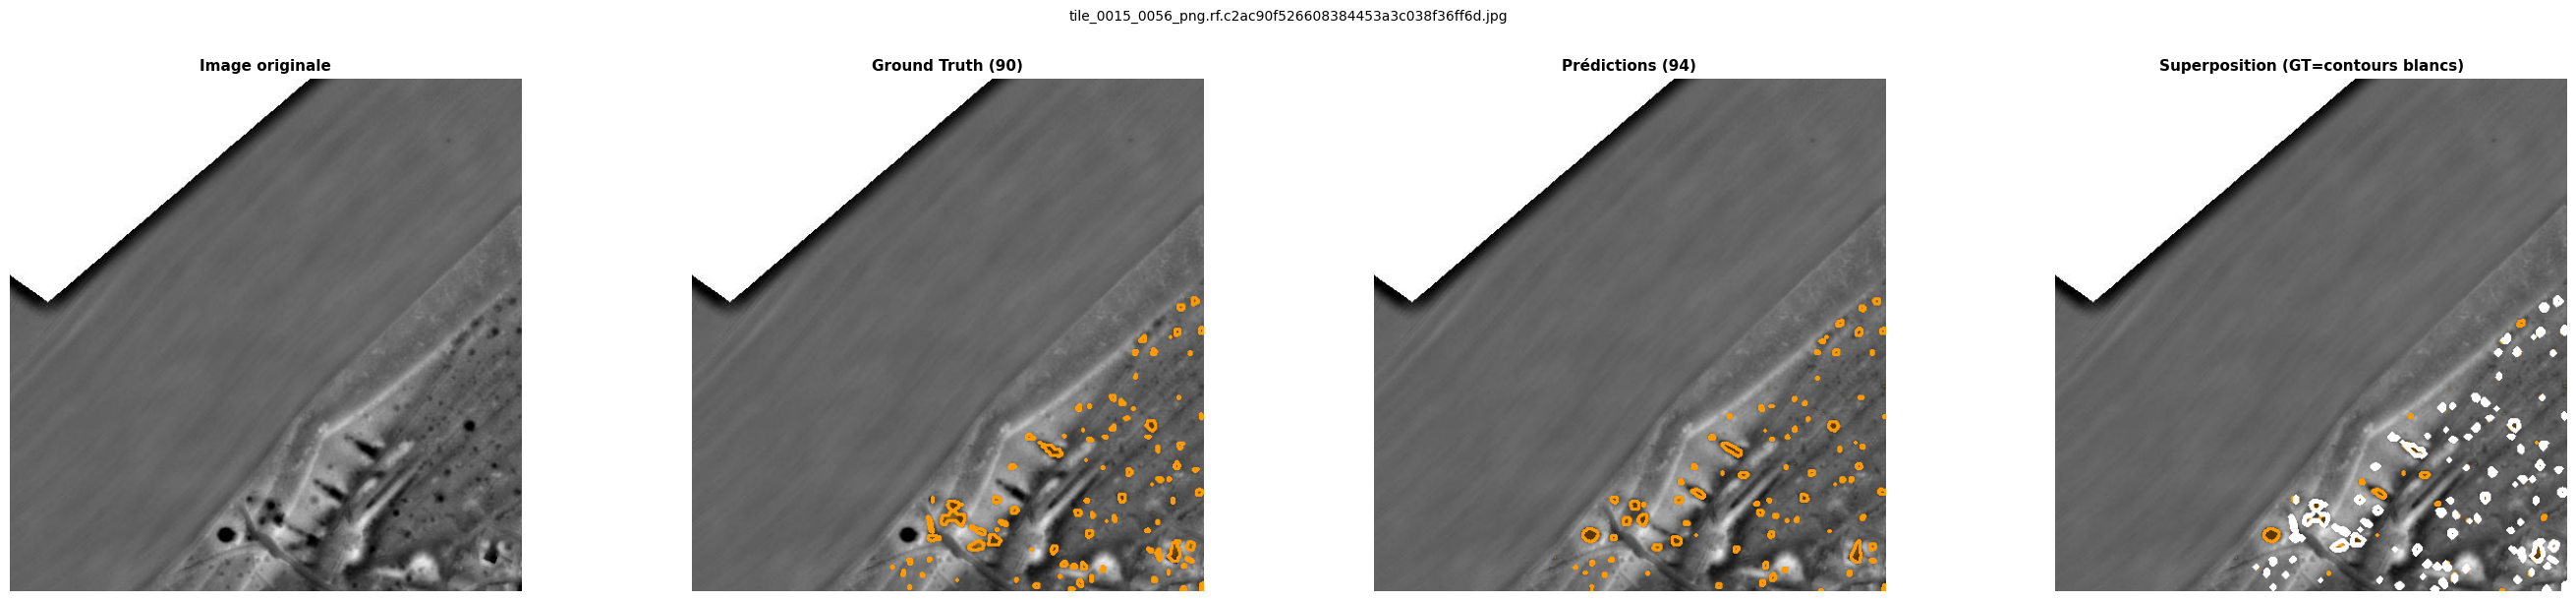

In [ ]:
_viz_dir_quick = os.path.join(DATASET_DIR, viz_split)
_ann_quick = os.path.join(_viz_dir_quick, '_annotations.coco.json')
_anns_by_img_q = defaultdict(list)
_imgs_by_name_q = {}
if os.path.exists(_ann_quick):
    with open(_ann_quick, 'r') as f:
        _cq = json.load(f)
    for _img in _cq['images']:
        _imgs_by_name_q[_img['file_name']] = _img
    for _ann in _cq['annotations']:
        _anns_by_img_q[_ann['image_id']].append(_ann)

_img_files = sorted([f for f in os.listdir(_viz_dir_quick)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])

# Afficher la légende
_legend = _make_legend_image(rfdetr_label_map)
plt.figure(figsize=(4,3)); plt.imshow(_legend); plt.axis('off')
plt.title("Légende", fontweight='bold'); plt.show()

n_show = min(4, len(_img_files))
np.random.seed(42)
_show_idx = np.random.choice(len(_img_files), n_show, replace=False)
for _si in _show_idx:
    print(f"\n📷 {_img_files[_si]}")
    visualize_prediction(model, os.path.join(_viz_dir_quick, _img_files[_si]),
                         rfdetr_label_map, rfdetr_class_map,
                         _anns_by_img_q, _imgs_by_name_q, TASK, CONFIDENCE_THRESHOLD)


## 15. Utilitaire : Prédiction sur Image Unique

In [ ]:

def predict_single_image(model, image_path, class_names, task=TASK,
                         threshold=0.3, save_path=None):
    """Prédit et affiche les résultats pour une seule image."""
    image = Image.open(image_path)
    detections = model.predict(image, threshold=threshold,
                                shape=(RESOLUTION, RESOLUTION))
    classes_dict = {i: n for i, n in enumerate(class_names)}
    annotated = annotate(image, detections, classes_dict, task)

    n_det = len(detections) if detections else 0
    print(f"\n📷 {os.path.basename(image_path)}: {n_det} détections")
    if detections.class_id is not None:
        for cid, conf in zip(detections.class_id, detections.confidence):
            print(f"   - {classes_dict.get(int(cid),'?')}: {conf:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(image); axes[0].set_title("Originale"); axes[0].axis('off')
    axes[1].imshow(annotated); axes[1].set_title(f"Prédiction ({n_det})"); axes[1].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   💾 {save_path}")
    plt.show()
    return detections


# Exemple d'utilisation :
# detections = predict_single_image(
#     model, "path/to/image.jpg", CLASS_NAMES,
#     task=TASK, threshold=CONFIDENCE_THRESHOLD,
#     save_path=os.path.join(TARGET_INFERENCE_PATH, "test_prediction.png")
# )

print("✅ Fonction predict_single_image définie")

# ============================================================================
# FIN DU PIPELINE
# ============================================================================
print(f"\n{'='*60}")
print(f"🏁 PIPELINE TERMINÉ")
print(f"{'='*60}")
print(f"   Tâche:      {TASK}")
print(f"   Run:        {FINAL_RUN_NAME}")
print(f"   Modèle:     RF-DETR {'Seg ' if TASK=='instance_segmentation' else ''}{MODEL_VARIANT.upper()}")
print(f"   Classes:    {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"   Training:   {TARGET_TRAINING_PATH}")
print(f"   Inférence:  {TARGET_INFERENCE_PATH}")
print(f"{'='*60}")


## 16. Packaging — produit `package/` conforme au contrat

Génère le sous-dossier `runs/training/<RUN_NAME>/package/` contenant les
fichiers texte standardisés (`model_card.yaml`, `args.yaml`, `classes.txt`,
`training_params.json`, `config.json`, `evaluation_results.json`) plus une
copie du meilleur checkpoint (`weights/best.pth`).

Pour finaliser l'installation dans le plugin :

1. Copier `package/` → `data/models/<RUN_NAME>/`.
2. `python dev/runner_onnx/export_to_onnx.py --model data/models/<RUN_NAME>/weights/best.pth --output data/models/<RUN_NAME>/weights/best.onnx`
3. `python scripts/validate_models_metadata.py data/models/<RUN_NAME>`


### Fichiers de traçabilité vs fichiers consommés par le plugin

Le packaging produit plusieurs fichiers, mais **le plugin QGIS ne lit que** :

| Fichier | Rôle |
|---|---|
| `model_card.yaml` | Métadonnées + couverture entité (classes, `derived_targets`, thresholds) |
| `args.yaml` | Hyperparams inférence (`imgsz`, `sahi`, `postprocess`, `clustering`) |
| `weights/best.onnx` (ou `best.pt` fallback) | Poids du modèle |
| `classes.txt` | Noms de classes (1 par ligne) |
| `weights/best.json` | Sidecar méta — produit par `export_to_onnx.py`, pas par ce notebook |

Les autres fichiers (`training_params.json`, `config.json`, `evaluation_results.json`)
sont produits pour la **traçabilité** (reproductibilité, audit, doc post-hoc) :
le plugin les ignore. Ils ne sont **pas** requis pour qu'un modèle soit détecté
par `discover_installed_models()`.


In [ ]:
# === STANDARDIZATION: packaging final ===
# Produit `runs/training/<RUN_NAME>/package/` conforme à docs/model_contract.md.
import json as _json
import shutil as _shutil
import yaml as _yaml
from pathlib import Path as _Path


def _class_color_indices(n_classes):
    """Palette runner_onnx (12 couleurs) cyclique par index de classe."""
    return [i % 12 for i in range(n_classes)]


def _build_args_yaml(inference, model_str, task_str, class_colors):
    args = {
        "model": model_str,
        "task": task_str,
        "imgsz": inference["imgsz"],
        "sahi": {
            "slice_width": inference["sahi"]["slice_width"],
            "slice_height": inference["sahi"]["slice_height"],
            "overlap_ratio": inference["sahi"]["overlap_ratio"],
        },
        "postprocess": {
            "merge_adjacent": inference["postprocess"]["merge_adjacent"],
            "remove_overlaps": inference["postprocess"]["remove_overlaps"],
        },
        "class_colors": list(class_colors),
    }
    if inference.get("clustering"):
        args["clustering"] = inference["clustering"]
    return args


def _build_model_card(meta, run, model_str, variant, classes_canon, labels_fr, color_indices,
                     inference, mnt, rvt, ui, training_resolution, derived_targets=None):
    classes_block = []
    for idx, (canon, fr, color) in enumerate(zip(classes_canon, labels_fr, color_indices)):
        classes_block.append({
            "id": idx,
            "name": canon,
            "label_fr": str(fr),
            "color_index": color,
            "description": "",
        })

    inference_choices = list(inference.get("inference_choices") or [])
    # Auto-détecte les divergences si non documentées
    documented = {ic.get("field") for ic in inference_choices if isinstance(ic, dict)}
    if inference["imgsz"] != training_resolution and "imgsz" not in documented:
        inference_choices.append({
            "field": "imgsz",
            "value": inference["imgsz"],
            "reason": f"imgsz inférence ({inference['imgsz']}) != résolution training ({training_resolution}) — à compléter.",
        })
    sahi_w = inference["sahi"]["slice_width"]
    if sahi_w != inference["imgsz"] and "sahi.slice_width" not in documented:
        inference_choices.append({
            "field": "sahi.slice_width",
            "value": sahi_w,
            "reason": f"SAHI slice_width ({sahi_w}) != imgsz ({inference['imgsz']}) — à compléter.",
        })
    sahi_h = inference["sahi"]["slice_height"]
    if sahi_h != inference["imgsz"] and "sahi.slice_height" not in documented:
        inference_choices.append({
            "field": "sahi.slice_height",
            "value": sahi_h,
            "reason": f"SAHI slice_height ({sahi_h}) != imgsz ({inference['imgsz']}) — à compléter.",
        })

    return {
        "id": meta["id"],
        "display_name": meta["display_name"] or meta["id"],
        "version": meta.get("version") or "",
        "status": meta.get("status") or "beta",
        "description": meta.get("description") or "",
        "task": run["task"],
        "architecture": model_str,
        "variant": variant,
        "resolution_train": training_resolution,
        "resolution_inference": inference["imgsz"],
        "preferred_rvt": {
            "type": rvt["type"],
            "params": dict(rvt["params"]),
        },
        "mnt": {
            "resolution": mnt["resolution"],
            "filter_expression": mnt["filter_expression"],
        },
        "classes": classes_block,
        "thresholds": {
            "confidence_default": ui["confidence_default"],
            "min_area_m2": ui["min_area_m2"],
        },
        **({"derived_targets": [
            {
                "output_class": dt["output_class"],
                "entity": dt["entity"],
                "include_source": bool(dt.get("include_source", True)),
                **({"output_label": dt["output_label"]} if dt.get("output_label") else {}),
                **({"source_label": dt["source_label"]} if dt.get("source_label") else {}),
            }
            for dt in (derived_targets or [])
        ]} if derived_targets else {}),
        "inference_choices": inference_choices,
        "recommended_use": meta.get("recommended_use") or "",
        "known_limitations": list(meta.get("known_limitations") or []),
    }


def _build_training_params(run, mnt, rvt, ui, training_resolution, variant):
    return {
        "description": "Paramètres utilisés pour générer les images d'entraînement de ce modèle",
        "model": {
            "architecture": run.get("architecture", "RF-DETR"),
            "variant": variant,
            "task": run["task"],
            "imgsz": training_resolution,
        },
        "mnt": {
            "resolution": mnt["resolution"],
            "filter_expression": mnt["filter_expression"],
        },
        "rvt": {
            "type": rvt["type"],
            "params": dict(rvt["params"]),
        },
        "detection": {"min_area_m2": ui["min_area_m2"]},
    }


def _build_config_json(run, training_resolution, classes_canon, training_dict, dataset_dict):
    return {
        "task": run["task"],
        "model": {
            "architecture": run.get("architecture", "RF-DETR"),
            "variant": run["variant"],
            "resolution": training_resolution,
            "num_classes": len(classes_canon),
            "class_names": list(classes_canon),
        },
        "training": dict(training_dict),
        "dataset": dict(dataset_dict),
        "inference": {"confidence_threshold": run.get("confidence_threshold", 0.3)},
    }


# ---- Construction des structures à partir des variables du notebook ----
_model_str_map = {
    ("object_detection", "base"): "RF-DETR",
    ("object_detection", "large"): "RF-DETR-Large",
    ("instance_segmentation", "nano"): "RF-DETR-Seg-Nano",
    ("instance_segmentation", "small"): "RF-DETR-Seg-Small",
    ("instance_segmentation", "medium"): "RF-DETR-Seg-Medium",
    ("instance_segmentation", "large"): "RF-DETR-Seg-Large",
}
_model_str = _model_str_map.get((TASK, MODEL_VARIANT), f"RF-DETR-{MODEL_VARIANT}")

_run = {
    "id": TARGET_NAME,
    "task": TASK,
    "variant": MODEL_VARIANT,
    "architecture": _model_str.split("-")[0] + "-DETR" if "DETR" in _model_str else "RF-DETR",
    "confidence_threshold": CONFIDENCE_THRESHOLD,
}

_class_colors = _class_color_indices(len(CANONICAL_CLASS_NAMES))

_args_yaml = _build_args_yaml(INFERENCE, _model_str, TASK, _class_colors)

_training_dict = {
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM_STEPS,
    "learning_rate": LEARNING_RATE,
    "lr_encoder": LR_ENCODER,
    "weight_decay": WEIGHT_DECAY,
    "lr_scheduler": LR_SCHEDULER,
    "warmup_epochs": WARMUP_EPOCHS,
    "lr_drop": LR_DROP,
    "freeze_at": FREEZE_AT,
    "use_amp": USE_AMP,
    "use_ema": USE_EMA,
    "gradient_checkpointing": GRADIENT_CHECKPOINTING,
    "early_stopping": EARLY_STOPPING,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "early_stopping_use_ema": EARLY_STOPPING_USE_EMA,
    "checkpoint_interval": CHECKPOINT_INTERVAL,
    "seed": SEED,
}

_dataset_dict = {
    "roboflow_workspace": ROBOFLOW_WORKSPACE,
    "roboflow_project": ROBOFLOW_PROJECT,
    "roboflow_version": ROBOFLOW_VERSION,
    "roboflow_url": ROBOFLOW_URL,
    "ignore_prefixes": list(IGNORE_PREFIXES),
    "ignore_classes": list(IGNORE_CLASSES),
}

_training_resolution = RESOLUTION

# Garde-fou : chaque DERIVED_TARGETS[i].output_class doit correspondre à une
# règle de clustering dans INFERENCE — sinon le plugin l'ignorera silencieusement.
_cluster_outputs = {
    str(r.get("output_class_name") or "").strip()
    for r in (INFERENCE.get("clustering") or [])
    if isinstance(r, dict)
}
_orphan_targets = [
    dt for dt in (DERIVED_TARGETS or [])
    if str(dt.get("output_class") or "").strip() not in _cluster_outputs
]
if _orphan_targets:
    print(
        f"⚠️  DERIVED_TARGETS sans règle de clustering correspondante : "
        f"{[dt.get('output_class') for dt in _orphan_targets]}. "
        f"Le plugin les ignorera. Vérifier INFERENCE['clustering'][i]['output_class_name']."
    )

_model_card = _build_model_card(
    MODEL_CARD_META, _run, _model_str, MODEL_VARIANT,
    CANONICAL_CLASS_NAMES, CLASS_LABELS_FR, _class_colors,
    INFERENCE, MNT, RVT, UI, _training_resolution,
    derived_targets=DERIVED_TARGETS,
)

_training_params = _build_training_params(_run, MNT, RVT, UI, _training_resolution, MODEL_VARIANT)
_config_json = _build_config_json(_run, _training_resolution, CANONICAL_CLASS_NAMES, _training_dict, _dataset_dict)

# ---- Écriture du package ----
_package_dir = _Path(TARGET_TRAINING_PATH) / "package"
(_package_dir / "weights").mkdir(parents=True, exist_ok=True)

with open(_package_dir / "model_card.yaml", "w", encoding="utf-8") as f:
    _yaml.safe_dump(_model_card, f, sort_keys=False, allow_unicode=True)

with open(_package_dir / "args.yaml", "w", encoding="utf-8") as f:
    _yaml.safe_dump(_args_yaml, f, sort_keys=False, allow_unicode=True)

(_package_dir / "classes.txt").write_text(
    "\n".join(CANONICAL_CLASS_NAMES) + "\n", encoding="utf-8"
)

with open(_package_dir / "training_params.json", "w", encoding="utf-8") as f:
    _json.dump(_training_params, f, indent=2, ensure_ascii=False)
    f.write("\n")

with open(_package_dir / "config.json", "w", encoding="utf-8") as f:
    _json.dump(_config_json, f, indent=2, ensure_ascii=False)
    f.write("\n")

# Copier evaluation_results.json si déjà produit
_eval_src = _Path(TARGET_TRAINING_PATH) / "evaluation_results.json"
if _eval_src.exists():
    _shutil.copy2(_eval_src, _package_dir / "evaluation_results.json")
else:
    print("⚠️  evaluation_results.json absent — sera à régénérer avant publication.")

# Copier le meilleur checkpoint
_ckpt_candidates = [
    _Path(TARGET_TRAINING_PATH) / "checkpoints" / "checkpoint_best_ema.pth",
    _Path(TARGET_TRAINING_PATH) / "output" / "checkpoint_best_ema.pth",
    _Path(TARGET_TRAINING_PATH) / "checkpoints" / "checkpoint_best_total.pth",
    _Path(TARGET_TRAINING_PATH) / "output" / "checkpoint_best_total.pth",
]
_ckpt_found = next((c for c in _ckpt_candidates if c.exists()), None)
if _ckpt_found is not None:
    _shutil.copy2(_ckpt_found, _package_dir / "weights" / "best.pth")
    print(f"✅ Checkpoint copié : {_ckpt_found.name} → {_package_dir / 'weights' / 'best.pth'}")
else:
    print("⚠️  Aucun checkpoint best.pth trouvé — à copier manuellement.")

print()
print(f"📦 Package prêt : {_package_dir}")
print("   Pour installer dans le plugin :")
print(f"     1. Copier {_package_dir.name}/ → data/models/{TARGET_NAME}/")
print(f"     2. python dev/runner_onnx/export_to_onnx.py \\")
print(f"            --model data/models/{TARGET_NAME}/weights/best.pth \\")
print(f"            --output data/models/{TARGET_NAME}/weights/best.onnx \\")
print(f"            --type rfdetr \\")
print(f"            --imgsz {RESOLUTION} \\")
print(f"            --opset 17")
print(f"        (le script auto-détecte RF-DETR vs Seg via args.yaml,")
print(f"         valide PyTorch vs ONNX sur dev/image_test/,")
print(f"         et écrit weights/best.json — sidecar méta)")
print(f"     3. python scripts/validate_models_metadata.py data/models/{TARGET_NAME}")


In [ ]:
# === Export ONNX — à exécuter APRÈS avoir copié package/ → data/models/<TARGET_NAME>/ ===
#
# Le script auto-détecte RF-DETR vs RF-DETR-Seg via args.yaml, ainsi que
# resolution / patch_size / hidden_dim depuis les poids. Il valide aussi
# PyTorch vs ONNX sur les images de dev/image_test/ et écrit weights/best.json
# (sidecar méta) + classes.txt à la racine du modèle.
#
# Décommentez la commande shell ci-dessous après installation locale du package.
# (Sous Jupyter/Colab, !commande exécute la commande shell — les {variables}
#  Python sont interpolées.)

# !python dev/runner_onnx/export_to_onnx.py \
#     --model data/models/{TARGET_NAME}/weights/best.pth \
#     --output data/models/{TARGET_NAME}/weights/best.onnx \
#     --type rfdetr \
#     --imgsz {RESOLUTION} \
#     --opset 17
